# ResPlan preprocessing pipeline

**Objective**
Prepare ResPlan floorplans up to the room-only, axis-grid-regularized, geometry-clean, narrow-gap-cleaned, and minimum-room-area-filtered representation, while also persisting and exporting the final selected preprocessing subset for visual checking.

**Workflow overview**
1. Load and normalize raw floorplans from `external/resplan/ResPlan.pkl`.
2. Remove near-duplicate and colinear room vertices on the raw geometry before any concavity counting.
3. Apply a cheap raw concavity preselection before rescaling so obviously irrelevant plans are skipped early.
4. Rescale the preselected plans and inspect the rescaling summary.
5. Estimate wall thickness and offset room polygons into wall space before non-room layers are discarded.
6. Keep only the main room polygons needed for decomposition and split multipart rooms into explicit polygon pieces.
7. Infer architectural horizontal and vertical axes from matching room edges with orthogonal family locking.
8. Keep boundary axes and only those internal axes that have enough merged support or at least one sufficiently long supporting edge.
9. Reconstruct room polygons on the architectural axis grid by assigning grid cells to the original room instances from the cell centers and simplify the merged cell unions immediately.
10. Close narrow double-wall gaps when two long parallel room edges are separated only by a tiny empty strip and one wall can safely be moved to the other.
11. Remove plans with room parts below `2.0 m^2`, then keep only the final `>=3`-concave subset for convex decomposition.
12. Save the final selected subset and export it to `output/figures/check` after clearing the previous gallery.


### Imports and dataset setup
One cell resolves the project paths, imports the shared preprocessing helpers, defines the main constants, and loads the raw `ResPlan.pkl` subset used in the current run.


In [1]:
# Standard library
import sys
import math
import pickle
import importlib
from pathlib import Path
from typing import Any, Dict, List, Tuple

# Third-party libraries
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry.base import BaseGeometry
from shapely.ops import unary_union


# Project paths

def get_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError(f"Couldn't find the ConvexDecomp project root starting at {start}")


PROJECT_ROOT = get_project_root(Path.cwd().resolve())
dataset_dir = PROJECT_ROOT / "external" / "resplan"
RESPLAN_DATA_DIR = PROJECT_ROOT / "data" / "ResPlan"
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "notebooks"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(dataset_dir) not in sys.path:
    sys.path.insert(0, str(dataset_dir))

from resplan_utils import (
    plot_plan,
    normalize_keys,
    compute_scale_from_meta,
    rescale_plan,
    plan_to_graph,
    area,
    CATEGORY_COLORS,
)
from notebooks.helpers import polygon_convexity as _polygon_convexity
from notebooks.helpers import room_geometry as _room_geometry

_polygon_convexity = importlib.reload(_polygon_convexity)
_room_geometry = importlib.reload(_room_geometry)

concave_polygon_count = _polygon_convexity.concave_polygon_count
annotate_plans_with_wall_thickness = _room_geometry.annotate_plans_with_wall_thickness
clean_raw_room_vertices = _room_geometry.clean_raw_room_vertices
clean_room_plan_geometries = _room_geometry.clean_room_plan_geometries
close_narrow_parallel_gaps = _room_geometry.close_narrow_parallel_gaps
count_plan_room_polygons = _room_geometry.count_plan_room_polygons
explode_polygon_parts = _room_geometry.explode_polygon_parts
grow_rooms_by_stored_wall_thickness = _room_geometry.grow_rooms_by_stored_wall_thickness
iter_plan_room_polygons = _room_geometry.iter_plan_room_polygons
open_concave_room_polygons = _room_geometry.open_concave_room_polygons
offset_rooms_into_walls = _room_geometry.offset_rooms_into_walls
plan_room_polygons = _room_geometry.plan_room_polygons
reduce_to_room_layers = _room_geometry.reduce_to_room_layers
scaled_room_polygons_above_area = _room_geometry.scaled_room_polygons_above_area


# Configuration
FP_COUNT = 50000  # Number of floorplans to process; set to None to use all plans
SEL_IDX = 0  # Index of a floorplan to show more details of
ROOM_KEYS = {"bathroom", "bedroom", "stair", "kitchen", "storage", "living"}
RAW_VERTEX_REL_TOL = 1e-5
RAW_VERTEX_ABS_TOL = 1e-6
MIN_AREA_M2 = 2.0
RAW_PRESELECTION_MIN_CONCAVE_ROOMS = 3
PRESELECTION_DROPPED_PREVIEW_COUNT = 6
MAX_WALL_PART_SAMPLES = 10
MIN_WALL_THICKNESS_M = 0.05
MAX_WALL_THICKNESS_M = 1.0
PRE_OFFSET_OPENING_SCALE = 0.5
PRE_OFFSET_OPENING_MIN_M = 0.05
PRE_OFFSET_OPENING_MAX_M = 0.2
PRE_OFFSET_MAX_AREA_LOSS_RATIO = 0.35
NARROW_GAP_MAX_M = 0.35
NARROW_GAP_MIN_PARALLEL_LENGTH_M = 1.5
NARROW_GAP_MIN_REFERENCE_OVERLAP_RATIO = 0.6
NARROW_GAP_MAX_COMPACTNESS_DROP = 0.08
SHOWCASE_PLAN_IDS = [10171, 13737, 12600]
SHOWCASE_PLAN_COUNT = 10  # Number of showcase plans to render; can exceed SHOWCASE_PLAN_IDS to allow fallback plans
GAP_CLEANUP_PREVIEW_COUNT = 6
TARGET_SLIVER_DIAGNOSTIC_IDS = [4111, 16228, 1491]
SLIVER_COMPACTNESS_THRESHOLD = 0.45


# Load the raw dataset
RESPLAN_PKL = dataset_dir / "ResPlan.pkl"
print(f"[ResPlan] dataset_dir={dataset_dir} | ResPlan.pkl exists={RESPLAN_PKL.exists()}")

with open(RESPLAN_PKL, "rb") as f:
    all_plans = pickle.load(f)

total_plan_count = len(all_plans)
effective_fp_count = total_plan_count if FP_COUNT is None else min(FP_COUNT, total_plan_count)

floorplans_all = [normalize_keys(plan) for plan in all_plans[:effective_fp_count]]
floorplans = floorplans_all
print(
    f"Loaded {len(floorplans_all)} floorplans out of {total_plan_count}. "
    f"Using indices 0..{len(floorplans_all) - 1}."
)


[ResPlan] dataset_dir=/Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/external/resplan | ResPlan.pkl exists=True
Loaded 17000 floorplans out of 17000. Using indices 0..16999.


### Clean near-duplicate and colinear raw room vertices
Call the shared room-geometry cleanup helper on the raw room polygons before any concavity counting.


In [2]:
floorplans_all_raw = floorplans_all
floorplans_all, raw_vertex_cleanup_stats = clean_raw_room_vertices(
    floorplans_all_raw,
    ROOM_KEYS,
    rel_tol=RAW_VERTEX_REL_TOL,
    abs_tol=RAW_VERTEX_ABS_TOL,
    normalize_plan=normalize_keys,
)
floorplans = floorplans_all

print(
    f"[Raw room vertex cleanup] Room vertices: {raw_vertex_cleanup_stats['before_vertices']} -> "
    f"{raw_vertex_cleanup_stats['after_vertices']} "
    f"(removed {raw_vertex_cleanup_stats['removed_vertices']})"
)
print(
    f"[Raw room vertex cleanup] Room geometries changed: "
    f"{raw_vertex_cleanup_stats['changed_room_geometries']}"
)


[Raw room vertex cleanup] Room vertices: 1191103 -> 1171679 (removed 19424)
[Raw room vertex cleanup] Room geometries changed: 5350


### Preselect plans with many concave rooms before rescaling

**Inputs:**
- `floorplans_all` raw normalized floorplans after early room-vertex cleanup
- Shared strict convexity helper `notebooks.helpers.polygon_convexity`
- `MIN_AREA_M2=2.0` used only to ignore raw room parts that would be too small after rescaling

**Steps:**
1. Estimate the metric scale factor of each raw plan without rescaling the full geometry.
2. Keep only room polygon parts whose scaled area already exceeds `MIN_AREA_M2`.
3. Count non-convex room polygons with the shared convexity helper and keep only plans with at least `3` concave rooms.
4. Collect a small balanced preview of dropped plans from the `0`, `1`, and `2` concave-room buckets for quick visual inspection.
5. Store the selected raw plans and their scale factors so only those candidates are rescaled downstream.

**Outputs:**
- `floorplans` reduced to the raw preselected candidate subset
- `preselected_scale_factors`
- `raw_hard_case_count_before`
- A small gallery of dropped low-concavity plans


[Raw concavity preselection] Plans with >=3 concave rooms before preprocessing: 11691 / 17000 (68.8%)
[Raw concavity preselection] Dropped plans with <3 concave rooms: 5309


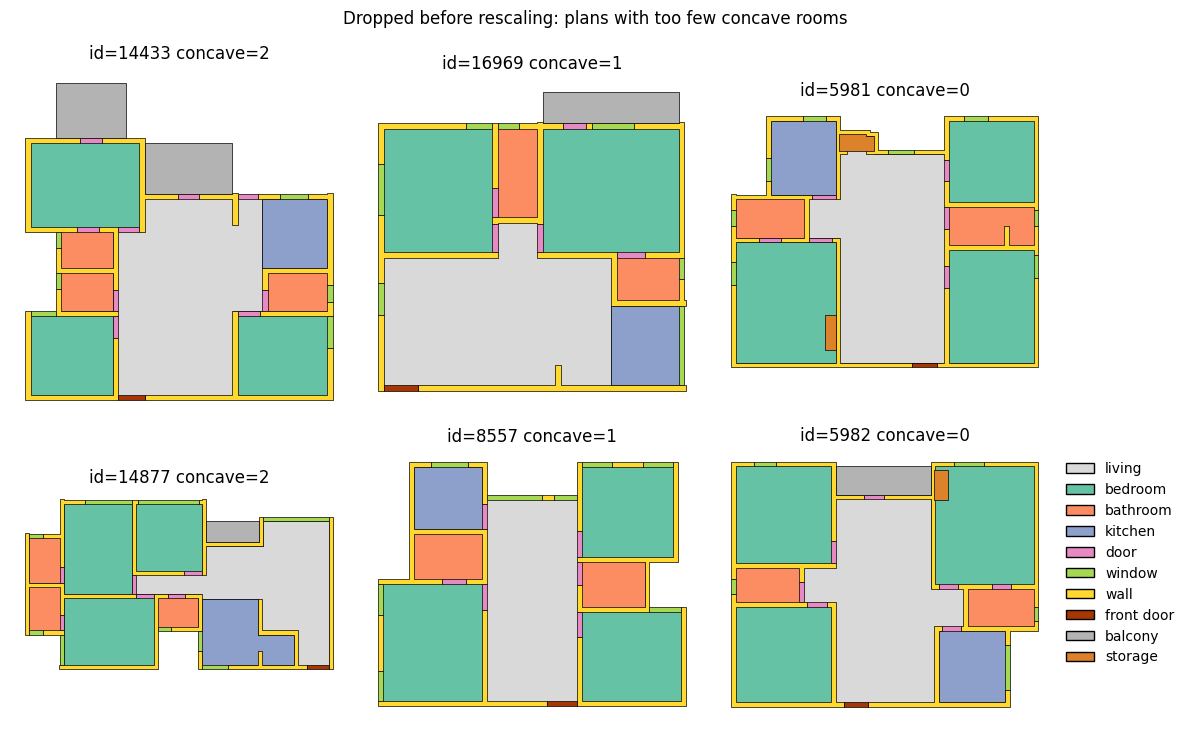

In [3]:
preselected_floorplans = []
preselected_scale_factors = []
dropped_preselection_records = []


def _select_dropped_preselection_examples(records, max_examples: int = PRESELECTION_DROPPED_PREVIEW_COUNT):
    buckets = {0: [], 1: [], 2: []}
    for record in records:
        bucket = min(int(record["concave_count"]), 2)
        buckets[bucket].append(record)

    selected = []
    while len(selected) < max_examples:
        added = False
        for bucket in (2, 1, 0):
            if buckets[bucket]:
                selected.append(buckets[bucket].pop(0))
                added = True
                if len(selected) >= max_examples:
                    break
        if not added:
            break
    return selected


def _plot_dropped_preselection_examples(records):
    examples = _select_dropped_preselection_examples(records)
    if not examples:
        return

    n = len(examples)
    ncols = min(3, n)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, record in zip(axes, examples):
        plot_plan(
            record["plan"],
            ax=ax,
            legend=(record is examples[-1]),
            title=f"id={record['id']} concave={record['concave_count']}",
        )
        ax.set_axis_off()

    for ax in axes[len(examples):]:
        ax.set_visible(False)

    fig.suptitle("Dropped before rescaling: plans with too few concave rooms")
    plt.tight_layout()
    plt.show()


for fp in floorplans_all:
    scale_factor = compute_scale_from_meta(fp)
    room_polys = scaled_room_polygons_above_area(fp, ROOM_KEYS, scale_factor, MIN_AREA_M2)
    concave_count = concave_polygon_count(room_polys)

    if concave_count >= RAW_PRESELECTION_MIN_CONCAVE_ROOMS:
        preselected_floorplans.append(fp)
        preselected_scale_factors.append(scale_factor)
    else:
        dropped_preselection_records.append({
            "id": fp.get("id"),
            "concave_count": int(concave_count),
            "plan": fp,
        })

floorplans = preselected_floorplans
raw_hard_case_count_before = len(floorplans)
raw_preselection_pct = 100.0 * raw_hard_case_count_before / len(floorplans_all) if floorplans_all else 0.0

print(
    f"[Raw concavity preselection] Plans with >=3 concave rooms before preprocessing: "
    f"{raw_hard_case_count_before} / {len(floorplans_all)} ({raw_preselection_pct:.1f}%)"
)
print(
    f"[Raw concavity preselection] Dropped plans with <3 concave rooms: "
    f"{len(dropped_preselection_records)}"
)

_plot_dropped_preselection_examples(dropped_preselection_records)


### Rescale the preselected floorplans
Rescale only the preselected plans and collect a small summary table with the scale factor and inner-footprint areas before and after rescaling.


In [4]:
def rescale_floorplans(floorplans: List[Dict[str, Any]], scale_factors: List[float]):
    rows = []
    out_plans = []

    for idx, (fp, scale_factor) in enumerate(zip(floorplans, scale_factors)):
        rescaled = rescale_plan(fp, scale_factor)

        wall_depth = fp.get("wall_depth")
        wall_thickness_m_estimate = (
            float(wall_depth) * float(scale_factor)
            if wall_depth is not None and float(wall_depth) > 0
            else None
        )
        if wall_thickness_m_estimate is not None:
            rescaled["wall_thickness_m_estimate"] = wall_thickness_m_estimate

        rows.append({
            "fp_no": idx,
            "id": fp.get("id"),
            "meta_area": fp.get("area"),
            "scale_factor": scale_factor,
            "wall_thickness_m_estimate": wall_thickness_m_estimate,
            "inner_area_before": area(fp.get("inner")) if fp.get("inner") is not None else None,
            "inner_area_after_rescale": area(rescaled.get("inner")) if rescaled.get("inner") is not None else None,
        })
        out_plans.append(rescaled)

    return out_plans, pd.DataFrame(rows)


rescaled_floorplans, df_summary = rescale_floorplans(floorplans, preselected_scale_factors)
print(f"Rescaled {len(rescaled_floorplans)} preselected floorplans.")
display(df_summary.head())


Rescaled 11691 preselected floorplans.


,fp_no,id,meta_area,scale_factor,wall_thickness_m_estimate,inner_area_before,inner_area_after_rescale
0,0,14926,84.541730,0.043915,0.225220,43837.397733,84.541730
1,1,5410,92.903000,0.047858,0.234108,40562.015498,92.903000
2,2,1448,230.863955,0.097909,0.322030,24083.140516,230.863955
3,3,14035,117.243586,0.072171,0.252228,22509.564737,117.243586
4,4,7067,63.174040,0.042503,0.167060,34970.905342,63.174040


### Estimate wall thickness, drop non-room layers, clean concave rooms, and then grow rooms
First estimate and store wall thickness on the rescaled plans, then discard walls / windows / doors early, run a conservative shrink-expand on concave room polygons without allowing room splits, and finally grow the cleaned rooms by half of the stored wall thickness.


In [5]:
rescaled_floorplans, wall_thickness_summary_df = annotate_plans_with_wall_thickness(
    rescaled_floorplans,
    normalize_plan=normalize_keys,
    max_wall_parts=MAX_WALL_PART_SAMPLES,
    min_thickness_m=MIN_WALL_THICKNESS_M,
    max_thickness_m=MAX_WALL_THICKNESS_M,
)

floorplans_rooms_pre_offset = reduce_to_room_layers(
    rescaled_floorplans,
    ROOM_KEYS,
    keep_keys=("id", "inner", "wall_thickness_m", "wall_thickness_source"),
)

floorplans_rooms_pre_offset, pre_offset_opening_stats = open_concave_room_polygons(
    floorplans_rooms_pre_offset,
    ROOM_KEYS,
    normalize_plan=normalize_keys,
    opening_tol_scale=PRE_OFFSET_OPENING_SCALE,
    min_opening_tol_m=PRE_OFFSET_OPENING_MIN_M,
    max_opening_tol_m=PRE_OFFSET_OPENING_MAX_M,
    max_area_loss_ratio=PRE_OFFSET_MAX_AREA_LOSS_RATIO,
)

room_offset_floorplans, room_offset_summary_df, wall_offset_fallback_count = grow_rooms_by_stored_wall_thickness(
    floorplans_rooms_pre_offset,
    ROOM_KEYS,
    normalize_plan=normalize_keys,
)

if not wall_thickness_summary_df.empty:
    valid_thickness = wall_thickness_summary_df[wall_thickness_summary_df["wall_thickness_m"] > 0]["wall_thickness_m"]
    if not valid_thickness.empty:
        print(
            f"Estimated wall thickness for {len(valid_thickness)} / {len(wall_thickness_summary_df)} plans "
            f"(median {valid_thickness.median():.3f} m, mean {valid_thickness.mean():.3f} m)."
        )
    else:
        print("No usable wall-thickness estimates found.")

print(
    f"[Pre-offset concave cleanup] Changed {pre_offset_opening_stats['plans_changed']} / {len(floorplans_rooms_pre_offset)} plans "
    f"and {pre_offset_opening_stats['changed_room_geometries']} room polygons "
    f"(removed {pre_offset_opening_stats['total_area_removed_m2']:.2f} m^2)."
)
print(
    f"[Pre-offset concave cleanup] Opening tolerance = clamp("
    f"{pre_offset_opening_stats['opening_tol_scale']:.2f} * wall_thickness, "
    f"{pre_offset_opening_stats['min_opening_tol_m']:.2f}, "
    f"{pre_offset_opening_stats['max_opening_tol_m']:.2f}) m; "
    f"max area loss ratio = {100.0 * pre_offset_opening_stats['max_area_loss_ratio']:.0f}%."
)
if pre_offset_opening_stats["rejected_split"] or pre_offset_opening_stats["rejected_area_loss"]:
    print(
        f"[Pre-offset concave cleanup] Rejected split candidates: "
        f"{pre_offset_opening_stats['rejected_split']}; "
        f"rejected high-area-loss candidates: {pre_offset_opening_stats['rejected_area_loss']}."
    )
if wall_offset_fallback_count:
    print(f"[Wall offset] Plans kept unchanged after topology fallback: {wall_offset_fallback_count}")

print(f"Applied collision-aware half-wall room offset to {len(room_offset_floorplans)} plans.")
display(room_offset_summary_df.head())


Estimated wall thickness for 11691 / 11691 plans (median 0.230 m, mean 0.237 m).
[Pre-offset concave cleanup] Changed 9663 / 11691 plans and 13932 room polygons (removed 2228.90 m^2).
[Pre-offset concave cleanup] Opening tolerance = clamp(0.50 * wall_thickness, 0.05, 0.20) m; max area loss ratio = 35%.
[Pre-offset concave cleanup] Rejected split candidates: 6220; rejected high-area-loss candidates: 14.
Applied collision-aware half-wall room offset to 11691 plans.


,id,wall_thickness_m,wall_thickness_source,room_area_before_m2,room_area_after_m2,room_growth_area_m2,offset_topology_fallback
0,14926,0.225220,wall_depth,81.372910,83.181327,1.808418,False
1,5410,0.234108,wall_depth,88.701167,90.561531,1.860364,False
2,1448,0.322030,wall_depth,238.980973,243.342148,4.361175,False
3,14035,0.252228,wall_depth,112.944954,115.406572,2.461618,False
4,7067,0.167060,wall_depth,61.518076,62.474872,0.956796,False


## Keep room polygons


### Keep only the room polygons
Drop the stored helper fields after the growth step so the downstream axis-inference pipeline works on room geometry only.


In [6]:
def _keep_room_layers(plans):
    return reduce_to_room_layers(plans, ROOM_KEYS, keep_keys=("id",))


floorplans_rooms = _keep_room_layers(room_offset_floorplans)

print(f"Built {len(floorplans_rooms)} reduced room plans before architectural-axis inference.")


Built 11691 reduced room plans before architectural-axis inference.


### Visualize the reduced room plans
Plot the first few reduced candidate plans before architectural-axis inference and axis-grid reconstruction.


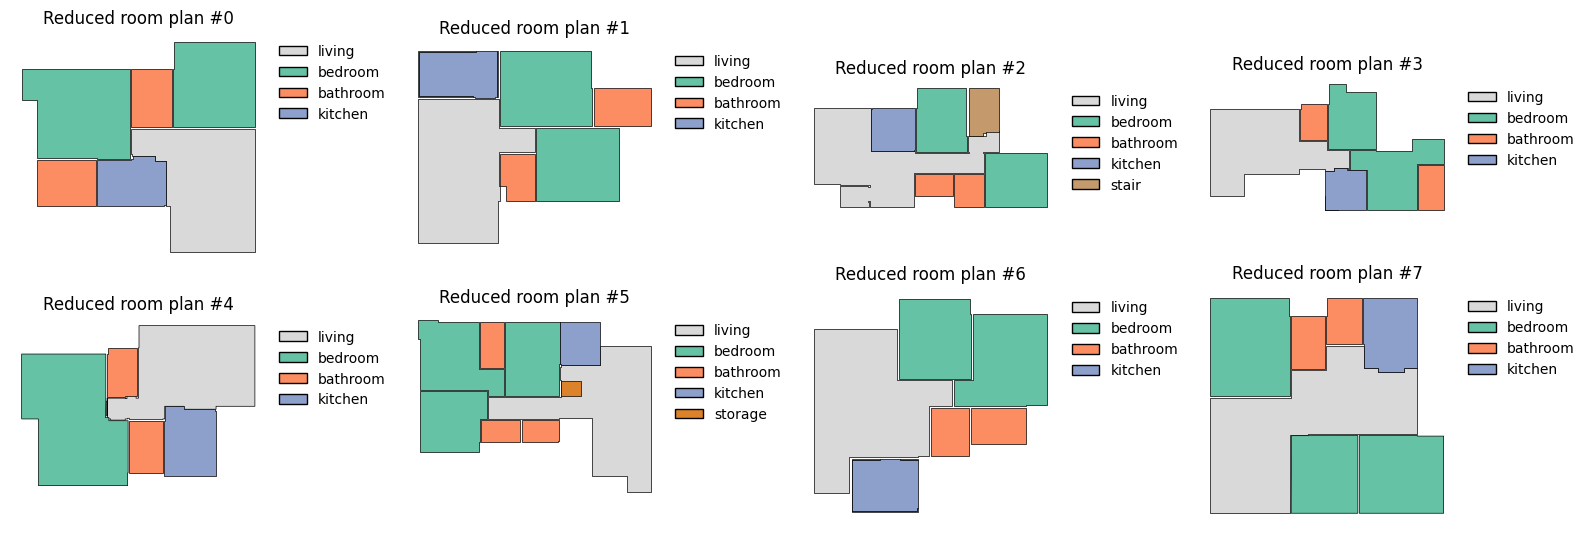

In [7]:
def plot_floorplans_grid(floorplans, ncols: int = 5, nrows: int = 2, title_prefix: str = "Plan"):
    max_plots = ncols * nrows
    n = min(len(floorplans), max_plots)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(n):
        ax = axes[i]
        plot_plan(floorplans[i], ax=ax, legend=True, title=f"{title_prefix} #{i}")
        ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_floorplans_grid(floorplans_rooms, ncols=4, nrows=2, title_prefix="Reduced room plan")


### Split multipolygon rooms into individual polygons
Split room geometries into explicit polygon parts and drop parts smaller than `MIN_AREA_M2` before axis inference.


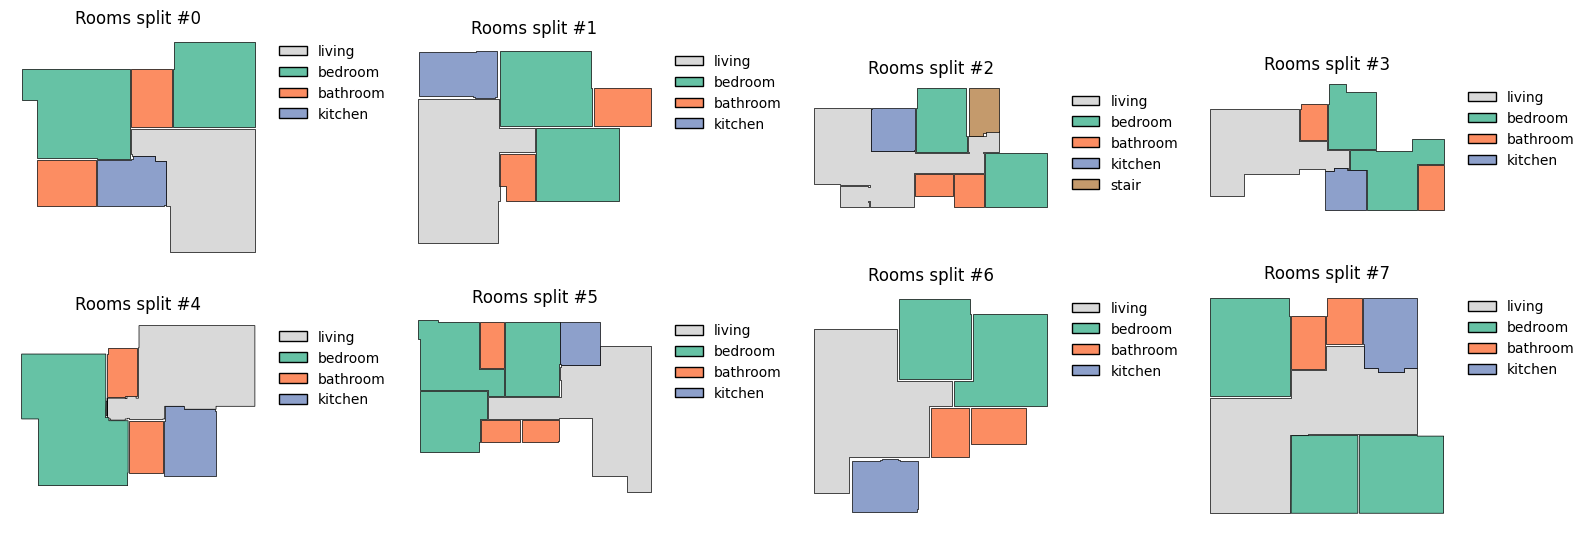

In [8]:
def split_room_plans(room_plans, min_area=MIN_AREA_M2):
    split_floorplans = []
    for rp in room_plans:
        rp_split = {"id": rp.get("id")}
        for key in ROOM_KEYS:
            geom = rp.get(key)
            polys = [poly for poly in explode_polygon_parts(geom) if poly.area >= min_area]
            if polys:
                rp_split[key] = polys
        split_floorplans.append(rp_split)
    return split_floorplans


floorplans_rooms_split = split_room_plans(floorplans_rooms, MIN_AREA_M2)
plot_floorplans_grid(floorplans_rooms_split, ncols=4, title_prefix="Rooms split")


## Regularize rooms on an architectural axis grid


### Infer architectural axes from matching room edges

**Inputs:**
- `floorplans_rooms_split` with explicit room polygon parts
- Axis tolerances `LINE_ANGLE_TOL_DEG=2.0`, `LINE_OFFSET_TOL_M=0.5`
- Axis-support filters `MIN_AXIS_SUPPORT_UNION_M=1.9`, `MIN_AXIS_SUPPORT_LONGEST_M=0.75`, `MIN_AXIS_MEMBER_LEN_M=1.5`

**Steps:**
1. Traverse all room edges in each plan and compute their line parameters.
2. Detect already orthogonal plans and lock their line families to horizontal and vertical only.
3. Cluster edges into architectural-axis bins without forcing a fixed number of bins.
4. Keep the outer boundary axes and filter internal axes by merged support and long-edge evidence.
5. Plot the first few room-only plans with the inferred architectural axes overlaid.
6. Summarize how many axes survive per plan after filtering.

**Outputs:**
- `floorplan_axes_data`
- `floorplan_axes_by_id`
- `axis_summary_df`


[Architectural axes] Orthogonal family-lock applied to 11137 / 11691 plans.
[Architectural axes] Mean kept axes per plan: 15.64 (vertical 7.39, horizontal 6.91)


,id,orthogonal_only,axis_count_before,axis_count_after,vertical_axes_after,horizontal_axes_after
0,14926,True,15,13,7,6
1,5410,True,14,12,6,6
2,1448,True,20,17,9,8
3,14035,True,19,18,10,8
4,7067,True,14,12,7,5


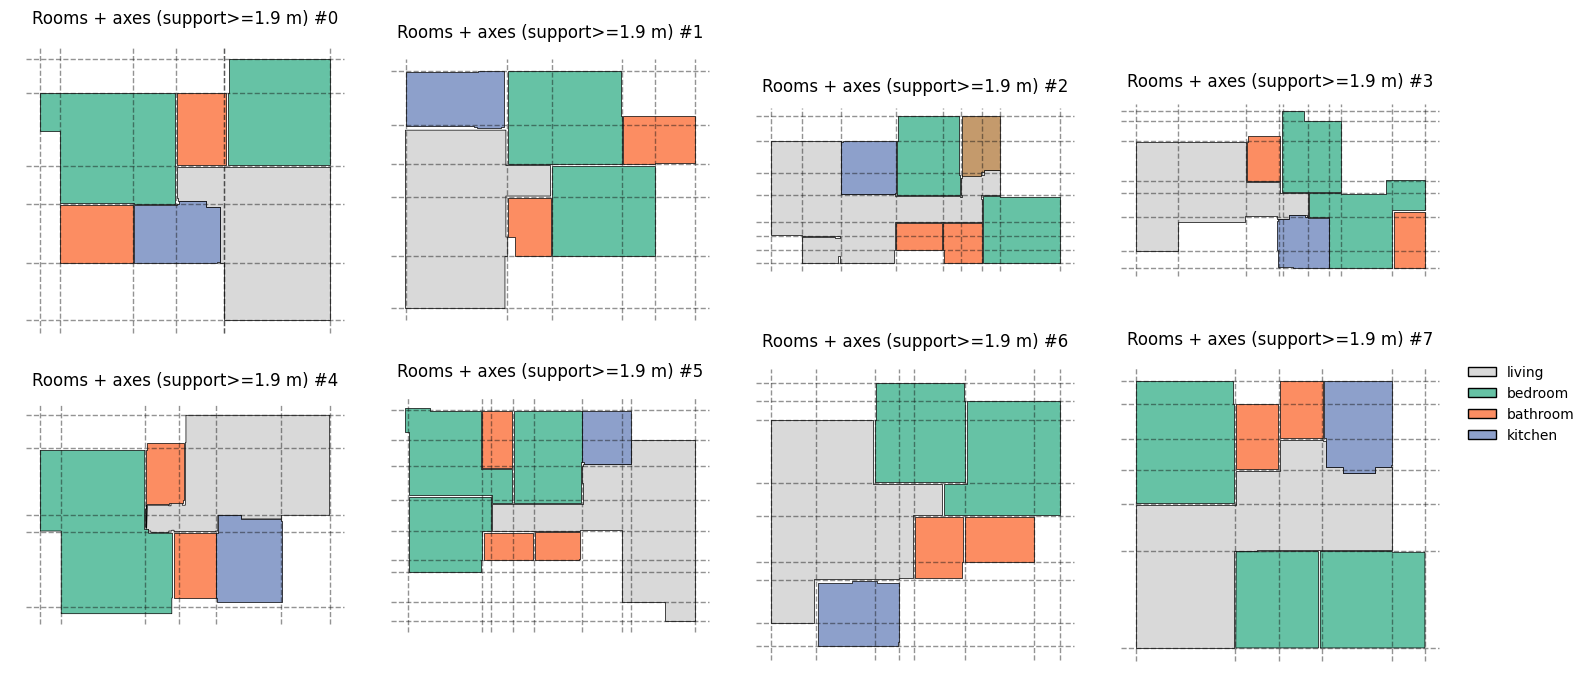

In [9]:
### Infer architectural axes from matching room edges + visualize

LINE_ANGLE_TOL_DEG = 2.0
LINE_OFFSET_TOL_M = 0.5
MIN_EDGE_LEN_M = 1e-12
ORTHOGONAL_PLAN_TOL_DEG = 5.0
ORTHOGONAL_MIN_EDGE_LEN_M = 0.15
MIN_AXIS_SUPPORT_UNION_M = 1.9
MIN_AXIS_SUPPORT_LONGEST_M = 0.75
MIN_AXIS_MEMBER_LEN_M = 1.5
AXIS_PREVIEW_COUNT = 8


def _iter_room_polygons(plan):
    for room_key, poly in iter_plan_room_polygons(plan, ROOM_KEYS, with_labels=True):
        yield room_key, poly


def _points_array(coords) -> np.ndarray:
    arr = np.asarray(coords, dtype=float)
    if len(arr) > 1 and np.allclose(arr[0], arr[-1]):
        arr = arr[:-1]
    return arr


def _ring_edges_all(points: np.ndarray) -> List[Tuple[np.ndarray, np.ndarray]]:
    n = len(points)
    return [(points[i], points[(i + 1) % n]) for i in range(n)] if n > 1 else []


def _edge_params(p: np.ndarray, q: np.ndarray):
    v = q - p
    L = float(np.linalg.norm(v))
    if L <= MIN_EDGE_LEN_M:
        d = np.array([1.0, 0.0], dtype=float)
    else:
        d = v / L
    n = np.array([-d[1], d[0]], dtype=float)
    rho = float(np.dot(n, p))
    if rho < 0:
        n = -n
        rho = -rho
    alpha = math.atan2(n[1], n[0])
    if alpha < 0:
        alpha += math.pi
    return alpha, rho, L, n, d


def _angle_diff(a: float, b: float) -> float:
    x = abs(a - b)
    return min(x, math.pi - x)


def _lines_from_alpha_rho(alpha: float, rho: float):
    n = np.array([math.cos(alpha), math.sin(alpha)], dtype=float)
    return n, float(rho)


def _edge_direction_folded_angle_deg(d: np.ndarray) -> float:
    theta = abs(math.degrees(math.atan2(float(d[1]), float(d[0]))))
    theta = theta % 180.0
    if theta > 90.0:
        theta = 180.0 - theta
    return theta


def _orthogonal_family_from_direction(d: np.ndarray, tol_deg: float = ORTHOGONAL_PLAN_TOL_DEG):
    theta = _edge_direction_folded_angle_deg(d)
    if theta <= tol_deg:
        return "horizontal"
    if abs(90.0 - theta) <= tol_deg:
        return "vertical"
    return None


def _canonical_alpha_for_family(family: str):
    if family == "vertical":
        return 0.0
    if family == "horizontal":
        return math.pi / 2.0
    return None


def _plan_is_orthogonal(edges: List[Dict], tol_deg: float = ORTHOGONAL_PLAN_TOL_DEG) -> bool:
    significant_edges = [e for e in edges if e["length"] >= ORTHOGONAL_MIN_EDGE_LEN_M]
    if not significant_edges:
        return False
    return all((e.get("family") or _orthogonal_family_from_direction(e["d"], tol_deg)) is not None for e in significant_edges)


def _cluster_edges(edges: List[Dict], angle_tol_deg: float, offset_tol: float, orthogonal_only: bool = False) -> List[Dict]:
    angle_tol = math.radians(angle_tol_deg)
    clusters = []
    for e in edges:
        family = e.get("family")
        a = e["alpha"]
        if orthogonal_only and family is not None:
            canonical_alpha = _canonical_alpha_for_family(family)
            if canonical_alpha is not None:
                a = canonical_alpha
        r, w = e["rho"], max(e["length"], MIN_EDGE_LEN_M)
        placed = False
        for cluster in clusters:
            if orthogonal_only and family is not None and cluster.get("family") != family:
                continue
            if _angle_diff(a, cluster["alpha"]) <= angle_tol and abs(r - cluster["rho"]) <= offset_tol:
                W = cluster["weight"] + w
                if orthogonal_only and family is not None:
                    cluster["alpha"] = _canonical_alpha_for_family(family)
                else:
                    cluster["alpha"] = (cluster["alpha"] * cluster["weight"] + a * w) / W
                cluster["rho"] = (cluster["rho"] * cluster["weight"] + r * w) / W
                cluster["weight"] = W
                cluster["members"].append(e)
                placed = True
                break
        if not placed:
            cluster = {"alpha": a, "rho": r, "weight": w, "members": [e]}
            if orthogonal_only and family is not None:
                cluster["family"] = family
            clusters.append(cluster)
    for cluster in clusters:
        cluster["n"], cluster["rho"] = _lines_from_alpha_rho(cluster["alpha"], cluster["rho"])
    return clusters


def _merged_intervals(intervals: List[Tuple[float, float]]) -> List[Tuple[float, float]]:
    if not intervals:
        return []
    ordered = sorted((min(a, b), max(a, b)) for a, b in intervals)
    merged = [ordered[0]]
    for start, end in ordered[1:]:
        prev_start, prev_end = merged[-1]
        if start <= prev_end + 1e-9:
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))
    return merged


def _cluster_support(cluster: Dict[str, Any]) -> Dict[str, float]:
    family = cluster.get("family")
    intervals = []
    max_member = 0.0
    for member in cluster["members"]:
        p = member["p"]
        q = member["q"]
        max_member = max(max_member, float(member["length"]))
        if family == "vertical":
            intervals.append((float(p[1]), float(q[1])))
        elif family == "horizontal":
            intervals.append((float(p[0]), float(q[0])))
    merged = _merged_intervals(intervals)
    union = sum(end - start for start, end in merged)
    longest = max((end - start) for start, end in merged) if merged else 0.0
    return {"union": union, "longest": longest, "max_member": max_member}


def _filter_clusters(clusters: List[Dict[str, Any]]) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    by_family = {"vertical": [], "horizontal": [], "other": []}
    for cluster in clusters:
        family = cluster.get("family")
        if family not in {"vertical", "horizontal"}:
            family = "other"
        cluster["support"] = _cluster_support(cluster)
        by_family[family].append(cluster)

    kept, removed = [], []
    for family, family_clusters in by_family.items():
        if family == "other":
            kept.extend(family_clusters)
            continue
        if not family_clusters:
            continue

        min_rho = min(cluster["rho"] for cluster in family_clusters)
        max_rho = max(cluster["rho"] for cluster in family_clusters)
        for cluster in family_clusters:
            is_boundary = abs(cluster["rho"] - min_rho) <= 1e-9 or abs(cluster["rho"] - max_rho) <= 1e-9
            support = cluster["support"]
            keep = is_boundary or (
                support["longest"] >= MIN_AXIS_SUPPORT_LONGEST_M
                and (
                    support["union"] >= MIN_AXIS_SUPPORT_UNION_M
                    or support["max_member"] >= MIN_AXIS_MEMBER_LEN_M
                )
            )
            if keep:
                kept.append(cluster)
            else:
                removed.append(cluster)

    kept.sort(key=lambda cluster: (cluster.get("family", ""), cluster["rho"]))
    removed.sort(key=lambda cluster: (cluster.get("family", ""), cluster["rho"]))
    return kept, removed


def _plan_bounds(plan: Dict[str, Any]):
    polys = [poly for _, poly in _iter_room_polygons(plan)]
    if not polys:
        return 0.0, 0.0, 1.0, 1.0
    minx = min(poly.bounds[0] for poly in polys)
    miny = min(poly.bounds[1] for poly in polys)
    maxx = max(poly.bounds[2] for poly in polys)
    maxy = max(poly.bounds[3] for poly in polys)
    return minx, miny, maxx, maxy


def _plan_axis_clusters(plan: Dict[str, Any]) -> Dict[str, Any]:
    edges = []
    for room_key, poly in _iter_room_polygons(plan):
        pts = _points_array(list(poly.exterior.coords))
        for p, q in _ring_edges_all(pts):
            alpha, rho, length, n, d = _edge_params(p, q)
            edges.append(
                {
                    "alpha": alpha,
                    "rho": rho,
                    "length": length,
                    "n": n,
                    "d": d,
                    "family": _orthogonal_family_from_direction(d),
                    "p": p,
                    "q": q,
                    "room_key": room_key,
                }
            )

    orthogonal_only = _plan_is_orthogonal(edges)
    clusters_before = _cluster_edges(edges, LINE_ANGLE_TOL_DEG, LINE_OFFSET_TOL_M, orthogonal_only=orthogonal_only)
    clusters_after, clusters_removed = _filter_clusters(clusters_before)
    return {
        "id": plan.get("id"),
        "orthogonal_only": orthogonal_only,
        "clusters_before": clusters_before,
        "clusters_after": clusters_after,
        "clusters_removed": clusters_removed,
    }


def _draw_cluster_axes(ax, clusters: List[Dict[str, Any]], bounds, orthogonal_only: bool):
    minx, miny, maxx, maxy = bounds
    pad_x = max(0.2, 0.05 * (maxx - minx))
    pad_y = max(0.2, 0.05 * (maxy - miny))
    xmin, xmax = minx - pad_x, maxx + pad_x
    ymin, ymax = miny - pad_y, maxy + pad_y

    for cluster in clusters:
        family = cluster.get("family")
        if orthogonal_only and family == "vertical":
            x = cluster["rho"]
            ax.plot([x, x], [ymin, ymax], linestyle="--", color="#111111", linewidth=1.0, alpha=0.45, zorder=10)
        elif orthogonal_only and family == "horizontal":
            y = cluster["rho"]
            ax.plot([xmin, xmax], [y, y], linestyle="--", color="#111111", linewidth=1.0, alpha=0.45, zorder=10)
        else:
            n = cluster["n"]
            rho = cluster["rho"]
            if abs(n[1]) > abs(n[0]):
                xs = np.array([xmin, xmax], dtype=float)
                ys = (rho - n[0] * xs) / n[1]
            else:
                ys = np.array([ymin, ymax], dtype=float)
                xs = (rho - n[1] * ys) / n[0]
            ax.plot(xs, ys, linestyle="--", color="#111111", linewidth=1.0, alpha=0.45, zorder=10)


def plot_floorplans_with_axes(plans: List[Dict[str, Any]], axes_by_id: Dict[int, Dict[str, Any]], ncols: int = 4, title_prefix: str = "Rooms + axes"):
    if not plans:
        return
    n = len(plans)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    axes = np.atleast_1d(axes).flatten()
    for idx, plan in enumerate(plans):
        ax = axes[idx]
        plot_plan(plan, ax=ax, legend=(idx == n - 1), title=f"{title_prefix} #{idx}")
        axis_info = axes_by_id.get(plan.get("id"))
        if axis_info is not None:
            _draw_cluster_axes(ax, axis_info["clusters_after"], _plan_bounds(plan), axis_info["orthogonal_only"])
        ax.set_axis_off()
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


floorplan_axes_data = [_plan_axis_clusters(plan) for plan in floorplans_rooms_split]
floorplan_axes_by_id = {item["id"]: item for item in floorplan_axes_data}

axis_summary_df = pd.DataFrame(
    {
        "id": [item["id"] for item in floorplan_axes_data],
        "orthogonal_only": [item["orthogonal_only"] for item in floorplan_axes_data],
        "axis_count_before": [len(item["clusters_before"]) for item in floorplan_axes_data],
        "axis_count_after": [len(item["clusters_after"]) for item in floorplan_axes_data],
        "vertical_axes_after": [sum(1 for c in item["clusters_after"] if c.get("family") == "vertical") for item in floorplan_axes_data],
        "horizontal_axes_after": [sum(1 for c in item["clusters_after"] if c.get("family") == "horizontal") for item in floorplan_axes_data],
    }
)

orthogonal_plan_count = int(axis_summary_df["orthogonal_only"].sum()) if not axis_summary_df.empty else 0
print(f"[Architectural axes] Orthogonal family-lock applied to {orthogonal_plan_count} / {len(floorplan_axes_data)} plans.")
if not axis_summary_df.empty:
    print(
        f"[Architectural axes] Mean kept axes per plan: {axis_summary_df['axis_count_after'].mean():.2f} "
        f"(vertical {axis_summary_df['vertical_axes_after'].mean():.2f}, horizontal {axis_summary_df['horizontal_axes_after'].mean():.2f})"
    )

display(axis_summary_df.head())
plot_floorplans_with_axes(
    floorplans_rooms_split[: min(AXIS_PREVIEW_COUNT, len(floorplans_rooms_split))],
    floorplan_axes_by_id,
    ncols=4,
    title_prefix=f"Rooms + axes (support>={MIN_AXIS_SUPPORT_UNION_M:.1f} m)",
)


### Reconstruct rooms on the architectural axis grid

**Inputs:**
- `floorplans_rooms_split` with explicit room polygon parts
- `floorplan_axes_by_id` with filtered architectural axes per plan
- Shared room-geometry cleanup helper for immediate simplification of merged cell unions

**Steps:**
1. Build the rectangular axis grid from the kept horizontal and vertical architectural axes.
2. Keep only grid cells whose centers lie inside the original room footprint.
3. Assign each kept cell to the original room instance that contains its center, with overlap fallback only when the midpoint is ambiguous.
4. Merge the assigned cells back into room polygons while preserving separate same-label room instances.
5. Simplify the reconstructed polygons immediately so straight grid runs do not keep one vertex per filled cell boundary.
6. Attach plan graphs, summarize the reconstruction error, and plot paired examples of the original room plan with axes and the cleaned axis-grid room plan.

**Outputs:**
- `floorplans_rooms_axis_grid`
- `axis_grid_reconstruction_summary_df`


[Axis-grid reconstruction] Reconstructed 11691 room-only plans on the inferred axis grid.
[Axis-grid reconstruction] Mean |ΔA|=12.00 m^2, mean Σsym=15.01 m^2
[Axis-grid reconstruction] Redundant vertices removed immediately after cell union: 781227 -> 476961 (removed 304266)


,id,x_axis_count,y_axis_count,midpoint_cells,overlap_cells,total_abs_area_error_m2,total_label_symdiff_m2
0,14926,7,6,18,0,2.663304,4.257738
1,5410,6,6,17,0,2.459264,5.001263
2,1448,9,8,47,0,6.449565,9.710421
3,14035,10,8,39,0,2.568332,7.901952
4,7067,7,5,18,0,1.066527,7.013819


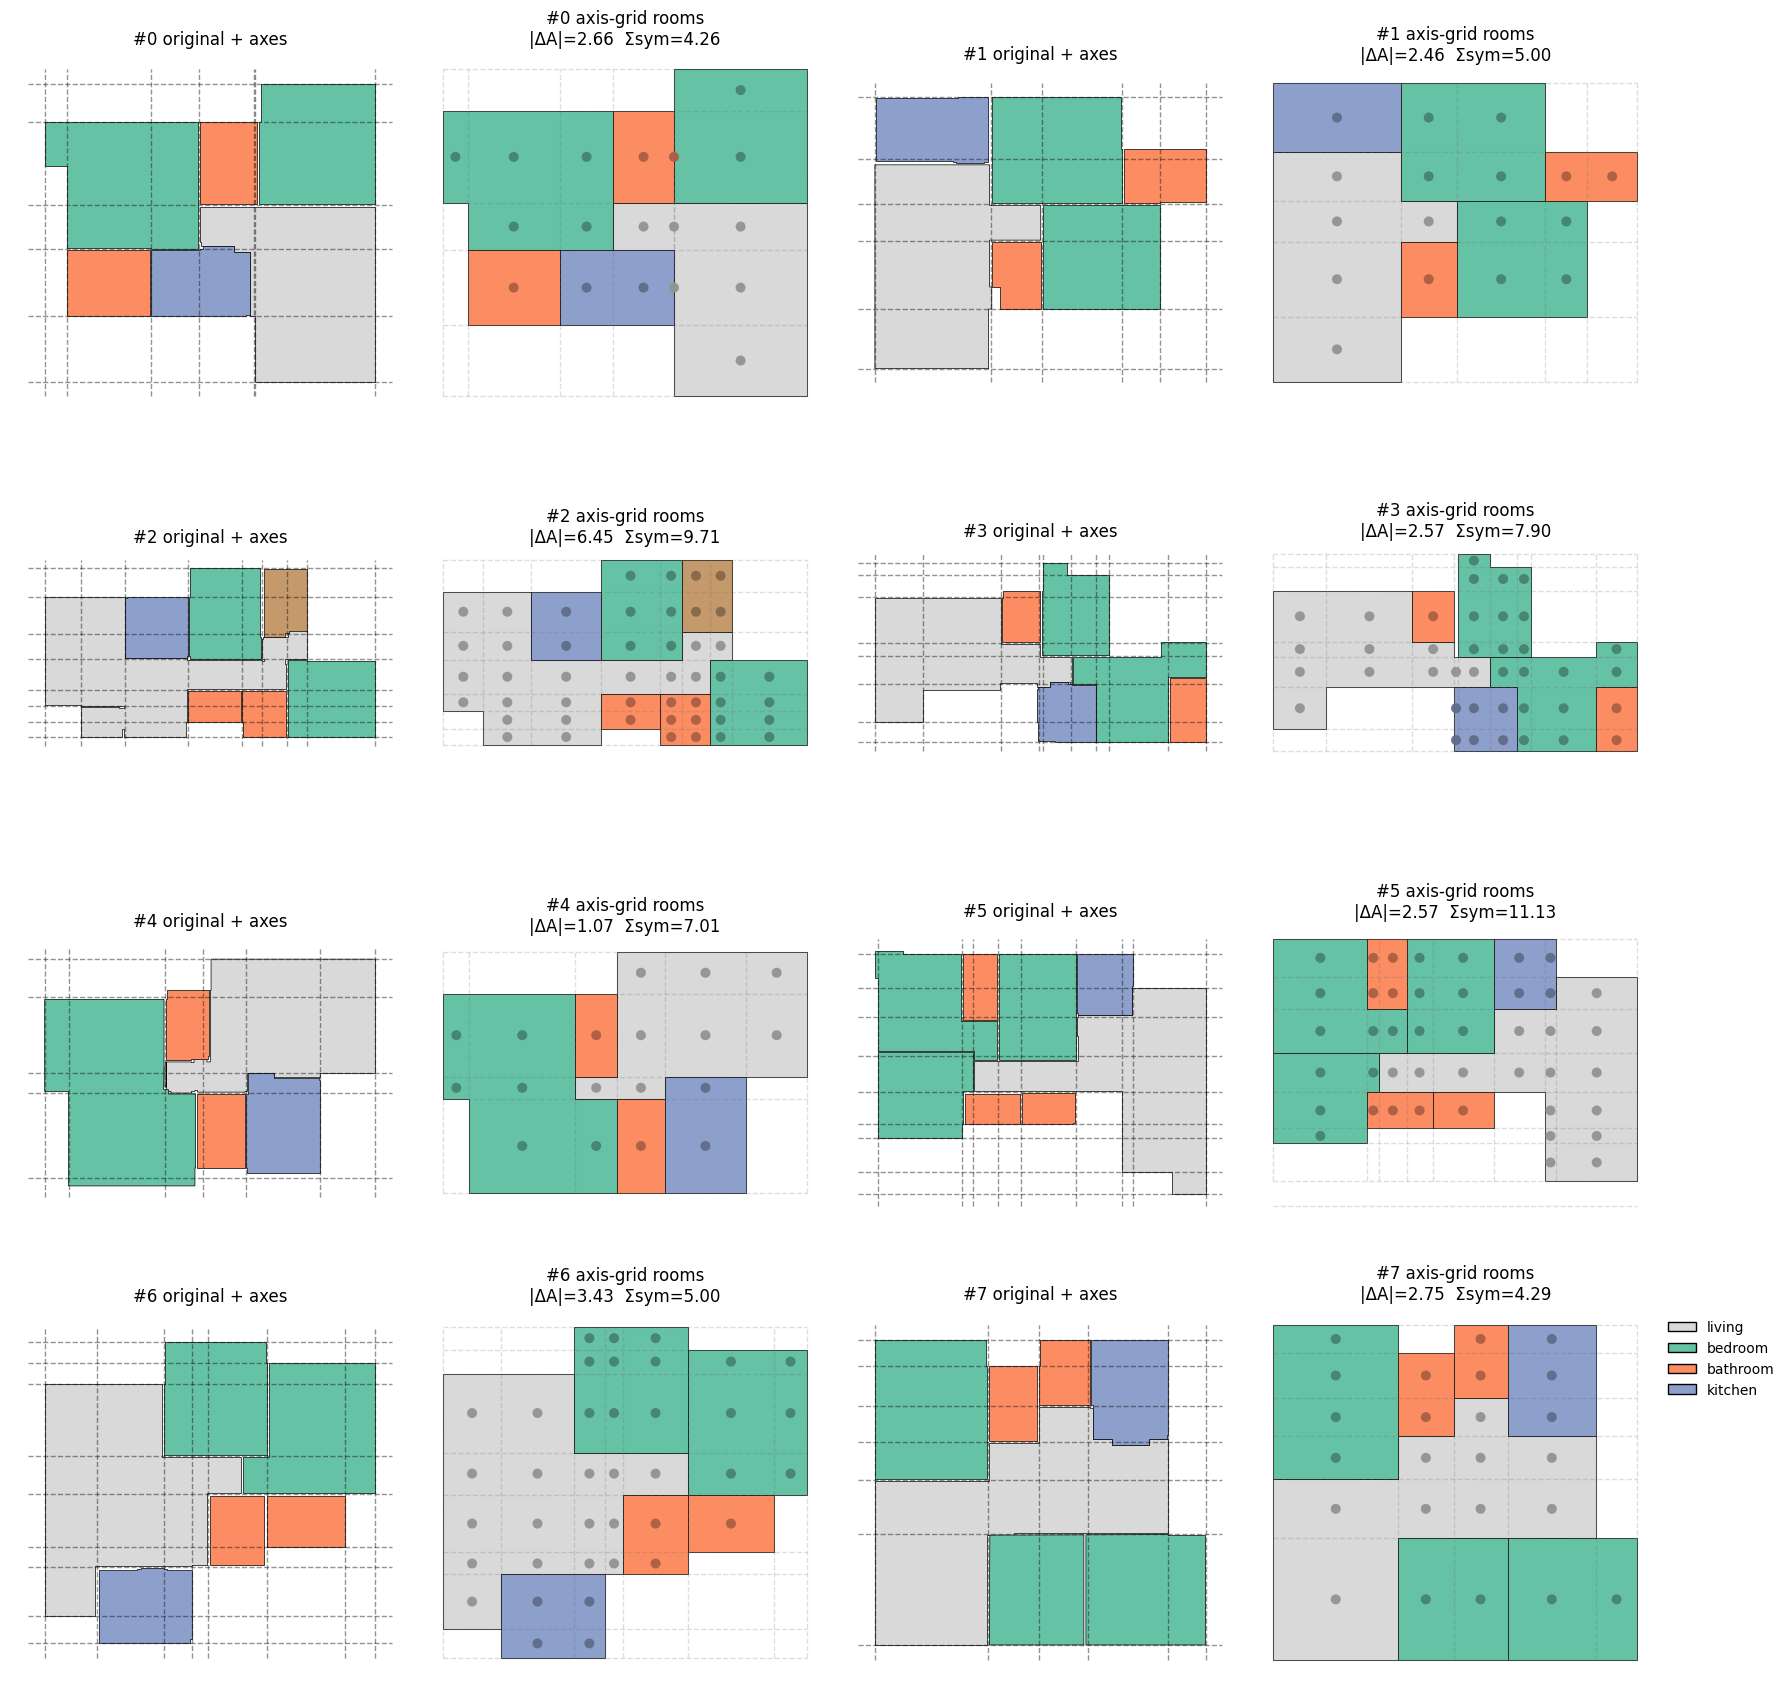

In [10]:
### Reconstruct rooms on the architectural axis grid + visualize

from collections import defaultdict
import matplotlib.colors as mcolors
from shapely.geometry import Point, box

AXIS_GRID_PREVIEW_COUNT = 8
AXIS_GRID_CENTER_MARKER_SIZE = 52
AXIS_GRID_GRIDLINE_COLOR = "#6b6b6b"
AXIS_GRID_GRIDLINE_ALPHA = 0.22
AXIS_GRID_CENTER_ALPHA = 0.96


def _room_instances(plan: Dict[str, Any]) -> List[Dict[str, Any]]:
    instances = []
    for room_key in ROOM_KEYS:
        for index, poly in enumerate(explode_polygon_parts(plan.get(room_key))):
            if isinstance(poly, Polygon) and not poly.is_empty:
                instances.append({
                    "instance_id": f"{room_key}__{index}",
                    "label": room_key,
                    "geometry": poly,
                })
    return instances


def _safe_union_polygons(polys):
    if not polys:
        return Polygon()
    geom = unary_union(polys)
    if isinstance(geom, BaseGeometry) and (not geom.is_empty) and (not geom.is_valid):
        geom = geom.buffer(0)
    return geom


def _unique_sorted(values: List[float], tol: float = 1e-6) -> List[float]:
    ordered = sorted(values)
    if not ordered:
        return []
    out = [ordered[0]]
    for value in ordered[1:]:
        if abs(value - out[-1]) > tol:
            out.append(value)
    return out


def _axis_grid_coordinates(axis_info: Dict[str, Any]) -> Tuple[List[float], List[float]]:
    xs = _unique_sorted([cluster["rho"] for cluster in axis_info["clusters_after"] if cluster.get("family") == "vertical"])
    ys = _unique_sorted([cluster["rho"] for cluster in axis_info["clusters_after"] if cluster.get("family") == "horizontal"])
    return xs, ys


def _assign_cell_to_room_instance(cell, center: Point, room_geoms: Dict[str, Polygon]) -> Tuple[str | None, str]:
    midpoint_hits = [room_id for room_id, geom in room_geoms.items() if geom.covers(center)]
    if len(midpoint_hits) == 1:
        return midpoint_hits[0], "midpoint"

    candidate_ids = midpoint_hits if midpoint_hits else list(room_geoms.keys())
    best_room_id = None
    best_overlap = 0.0
    for room_id in candidate_ids:
        overlap = room_geoms[room_id].intersection(cell).area
        if overlap > best_overlap + 1e-9:
            best_overlap = overlap
            best_room_id = room_id
    if best_room_id is not None and best_overlap > 1e-9:
        return best_room_id, "overlap"
    return None, "unassigned"


def _darken_room_color(room_key: str, factor: float = 0.68):
    base = CATEGORY_COLORS.get(room_key, "#666666")
    rgb = np.array(mcolors.to_rgb(base), dtype=float)
    if rgb.mean() > 0.92:
        return "#555555"
    return tuple(np.clip(rgb * factor, 0.0, 1.0))


def _draw_axis_grid_lines(ax, xs: List[float], ys: List[float], bounds: Tuple[float, float, float, float]):
    minx, miny, maxx, maxy = bounds
    for x in xs:
        ax.plot([x, x], [miny, maxy], linestyle="--", color=AXIS_GRID_GRIDLINE_COLOR, linewidth=1.0, alpha=AXIS_GRID_GRIDLINE_ALPHA, zorder=6)
    for y in ys:
        ax.plot([minx, maxx], [y, y], linestyle="--", color=AXIS_GRID_GRIDLINE_COLOR, linewidth=1.0, alpha=AXIS_GRID_GRIDLINE_ALPHA, zorder=6)


def plot_axis_grid_rooms(ax, plan: Dict[str, Any], axis_info: Dict[str, Any], metrics: Dict[str, Any], *, legend: bool = False, title: str | None = None):
    plot_plan(plan, ax=ax, legend=legend, title=title, tight=False)
    xs = metrics.get("grid_xs") or _axis_grid_coordinates(axis_info)[0]
    ys = metrics.get("grid_ys") or _axis_grid_coordinates(axis_info)[1]
    _draw_axis_grid_lines(ax, xs, ys, _plan_bounds(plan))
    for record in metrics.get("cell_records", []):
        center = record["center"]
        ax.scatter(
            [center.x],
            [center.y],
            s=AXIS_GRID_CENTER_MARKER_SIZE,
            color=[_darken_room_color(record["label"])],
            edgecolors="none",
            alpha=AXIS_GRID_CENTER_ALPHA,
            zorder=12,
        )
    ax.set_axis_off()


def reconstruct_plan_on_axis_grid(plan: Dict[str, Any], axis_info: Dict[str, Any]):
    room_instances = _room_instances(plan)
    instance_meta = {item["instance_id"]: item for item in room_instances}
    room_geoms = {item["instance_id"]: item["geometry"] for item in room_instances}
    footprint = _safe_union_polygons(list(room_geoms.values()))
    xs, ys = _axis_grid_coordinates(axis_info)

    cell_assignments = defaultdict(list)
    cell_records = []
    assignment_counts = {"midpoint": 0, "overlap": 0, "unassigned": 0, "outside": 0}

    for x0, x1 in zip(xs[:-1], xs[1:]):
        for y0, y1 in zip(ys[:-1], ys[1:]):
            if x1 - x0 <= 1e-9 or y1 - y0 <= 1e-9:
                continue
            cell = box(x0, y0, x1, y1)
            center = Point((x0 + x1) / 2.0, (y0 + y1) / 2.0)
            if not footprint.covers(center):
                assignment_counts["outside"] += 1
                continue
            room_id, mode = _assign_cell_to_room_instance(cell, center, room_geoms)
            assignment_counts[mode] += 1
            if room_id is not None:
                cell_assignments[room_id].append(cell)
                cell_records.append({
                    "instance_id": room_id,
                    "label": instance_meta[room_id]["label"],
                    "cell": cell,
                    "center": center,
                })

    reconstructed = {"id": plan.get("id")}
    if "neighbor" in plan:
        reconstructed["neighbor"] = plan["neighbor"]

    reconstructed_by_label = defaultdict(list)
    for item in room_instances:
        geom = _safe_union_polygons(cell_assignments.get(item["instance_id"], []))
        polys = explode_polygon_parts(geom)
        if polys:
            reconstructed_by_label[item["label"]].extend(polys)
    for room_key, polys in reconstructed_by_label.items():
        reconstructed[room_key] = polys
    reconstructed["graph"] = plan_to_graph(reconstructed)

    original_by_label = defaultdict(list)
    for item in room_instances:
        original_by_label[item["label"]].append(item["geometry"])

    total_abs_area_error = 0.0
    total_label_symdiff = 0.0
    room_metrics = []
    for room_key in sorted(original_by_label):
        original_geom = _safe_union_polygons(original_by_label[room_key])
        reconstructed_geom = _safe_union_polygons(reconstructed_by_label.get(room_key, []))
        original_area = float(original_geom.area)
        reconstructed_area = float(reconstructed_geom.area)
        area_diff = reconstructed_area - original_area
        symdiff_area = float(original_geom.symmetric_difference(reconstructed_geom).area)
        total_abs_area_error += abs(area_diff)
        total_label_symdiff += symdiff_area
        room_metrics.append(
            {
                "label": room_key,
                "original_area_m2": original_area,
                "reconstructed_area_m2": reconstructed_area,
                "area_diff_m2": area_diff,
                "symdiff_area_m2": symdiff_area,
            }
        )

    return reconstructed, {
        "assignment_counts": assignment_counts,
        "total_abs_area_error_m2": total_abs_area_error,
        "total_label_symdiff_m2": total_label_symdiff,
        "room_metrics": room_metrics,
        "x_axis_count": len(xs),
        "y_axis_count": len(ys),
        "grid_xs": xs,
        "grid_ys": ys,
        "cell_records": cell_records,
    }


def plot_axis_grid_reconstruction_pairs(original_plans, reconstructed_plans, axes_by_id, metrics_by_id):
    n = min(AXIS_GRID_PREVIEW_COUNT, len(original_plans))
    if n == 0:
        return
    nrows = int(math.ceil(n / 2))
    fig, axes = plt.subplots(nrows, 4, figsize=(18, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for idx in range(n):
        original_plan = original_plans[idx]
        reconstructed_plan = reconstructed_plans[idx]
        axis_info = axes_by_id[original_plan["id"]]
        metrics = metrics_by_id[original_plan["id"]]

        ax_left = axes[idx * 2]
        plot_plan(original_plan, ax=ax_left, legend=False, title=f"#{idx} original + axes")
        _draw_cluster_axes(ax_left, axis_info["clusters_after"], _plan_bounds(original_plan), axis_info["orthogonal_only"])
        ax_left.set_axis_off()

        ax_right = axes[idx * 2 + 1]
        plot_axis_grid_rooms(
            ax_right,
            reconstructed_plan,
            axis_info,
            metrics,
            legend=(idx == n - 1),
            title=(
                f"#{idx} axis-grid rooms\n"
                f"|ΔA|={metrics['total_abs_area_error_m2']:.2f}  Σsym={metrics['total_label_symdiff_m2']:.2f}"
            ),
        )

    for ax in axes[n * 2:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


axis_grid_results = []
floorplans_rooms_axis_grid = []
axis_grid_metrics_by_id = {}
for plan in floorplans_rooms_split:
    axis_info = floorplan_axes_by_id[plan["id"]]
    reconstructed_plan, metrics = reconstruct_plan_on_axis_grid(plan, axis_info)
    floorplans_rooms_axis_grid.append(reconstructed_plan)
    axis_grid_metrics_by_id[plan["id"]] = metrics
    axis_grid_results.append(
        {
            "id": plan["id"],
            "x_axis_count": metrics["x_axis_count"],
            "y_axis_count": metrics["y_axis_count"],
            "midpoint_cells": metrics["assignment_counts"]["midpoint"],
            "overlap_cells": metrics["assignment_counts"]["overlap"],
            "total_abs_area_error_m2": metrics["total_abs_area_error_m2"],
            "total_label_symdiff_m2": metrics["total_label_symdiff_m2"],
        }
    )

floorplans_rooms_axis_grid, geometry_cleanup_stats = clean_room_plan_geometries(
    floorplans_rooms_axis_grid,
    ROOM_KEYS,
    simplify_tol=1e-9,
    normalize_plan=normalize_keys,
    graph_builder=plan_to_graph,
)

axis_grid_reconstruction_summary_df = pd.DataFrame(axis_grid_results)
print(f"[Axis-grid reconstruction] Reconstructed {len(floorplans_rooms_axis_grid)} room-only plans on the inferred axis grid.")
if not axis_grid_reconstruction_summary_df.empty:
    print(
        f"[Axis-grid reconstruction] Mean |ΔA|={axis_grid_reconstruction_summary_df['total_abs_area_error_m2'].mean():.2f} m^2, "
        f"mean Σsym={axis_grid_reconstruction_summary_df['total_label_symdiff_m2'].mean():.2f} m^2"
    )
print(
    f"[Axis-grid reconstruction] Redundant vertices removed immediately after cell union: "
    f"{geometry_cleanup_stats['before_vertices']} -> {geometry_cleanup_stats['after_vertices']} "
    f"(removed {geometry_cleanup_stats['removed_vertices']})"
)
if geometry_cleanup_stats['degenerate_rooms_removed']:
    print(
        f"[Axis-grid reconstruction] Degenerate reconstructed room parts removed: "
        f"{geometry_cleanup_stats['degenerate_rooms_removed']}"
    )

display(axis_grid_reconstruction_summary_df.head())
plot_axis_grid_reconstruction_pairs(
    floorplans_rooms_split,
    floorplans_rooms_axis_grid,
    floorplan_axes_by_id,
    axis_grid_metrics_by_id,
)


### Close narrow parallel double-wall gaps

**Inputs:**
- `floorplans_rooms_axis_grid` immediately after axis-grid reconstruction
- `floorplans_rooms_split` as the reference room partition before reconstruction
- Narrow-gap thresholds `NARROW_GAP_MAX_M=0.35` and `NARROW_GAP_MIN_PARALLEL_LENGTH_M=1.5`

**Steps:**
1. Detect only tiny empty strips that lie between two parallel room edges with enough shared length.
2. Use the pre-grid room partition as a reference so exterior empty space is not mistaken for a double wall.
3. Test moving either wall to the other one, reject moves that would create overlaps, and keep the smaller relative room change if both directions are valid.
4. Rebuild plan graphs, run a light geometric cleanup again, and plot a small before/after gallery of changed plans.

**Outputs:**
- `axis_grid_showcase_before_gap_cleanup`
- `floorplans_rooms_axis_grid` after narrow-gap cleanup
- `gap_cleanup_stats`
- `gap_cleanup_examples`


[Narrow-gap cleanup] Changed 29 / 11691 plans by closing 37 narrow gap(s).
[Narrow-gap cleanup] Thresholds: gap <= 0.35 m, parallel support >= 1.50 m, reference overlap >= 60%, compactness drop <= 0.08, total absorbed area = 24.60 m^2.
[Narrow-gap cleanup] Immediate geometry cleanup after wall moves: 477021 -> 476969 (removed 52).


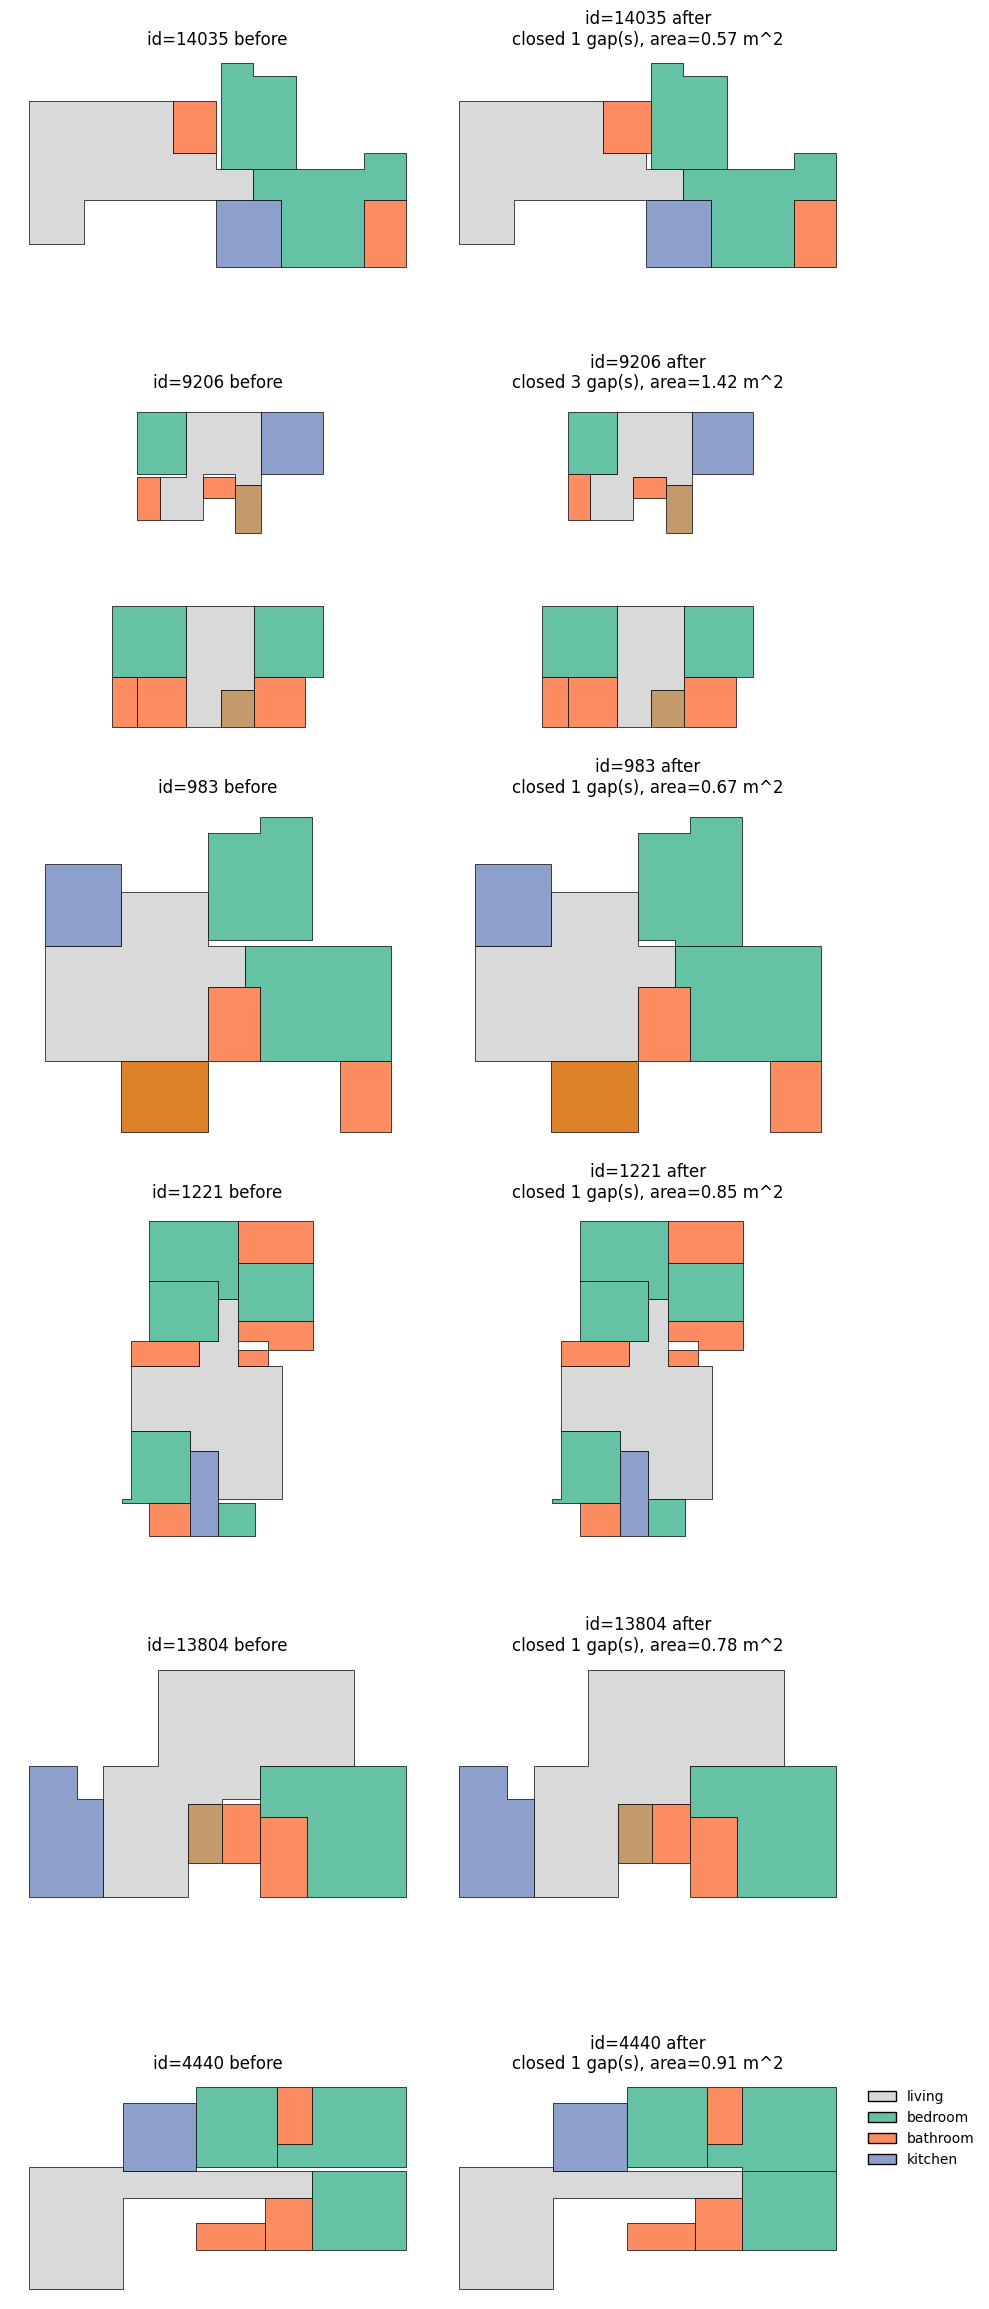

In [11]:
def plot_gap_cleanup_examples(examples, max_examples: int = GAP_CLEANUP_PREVIEW_COUNT):
    n = min(max_examples, len(examples))
    if n == 0:
        return
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    axes = np.atleast_2d(axes)
    for row, example in enumerate(examples[:n]):
        before_ax, after_ax = axes[row]
        move_count = len(example["moves"])
        total_strip_area = sum(move["strip_area_m2"] for move in example["moves"])
        plot_plan(example["before"], ax=before_ax, legend=False, title=f"id={example['id']} before")
        before_ax.set_axis_off()
        plot_plan(
            example["after"],
            ax=after_ax,
            legend=(row == n - 1),
            title=f"id={example['id']} after\nclosed {move_count} gap(s), area={total_strip_area:.2f} m^2",
        )
        after_ax.set_axis_off()
    plt.tight_layout()
    plt.show()


axis_grid_showcase_before_gap_cleanup = {
    plan.get("id"): plan
    for plan in floorplans_rooms_axis_grid
}

floorplans_rooms_axis_grid, gap_cleanup_stats, gap_cleanup_examples = close_narrow_parallel_gaps(
    floorplans_rooms_axis_grid,
    floorplans_rooms_split,
    ROOM_KEYS,
    max_gap_m=NARROW_GAP_MAX_M,
    min_parallel_length_m=NARROW_GAP_MIN_PARALLEL_LENGTH_M,
    min_reference_overlap_ratio=NARROW_GAP_MIN_REFERENCE_OVERLAP_RATIO,
    max_compactness_drop=NARROW_GAP_MAX_COMPACTNESS_DROP,
    normalize_plan=normalize_keys,
    graph_builder=plan_to_graph,
    max_examples=GAP_CLEANUP_PREVIEW_COUNT,
)

floorplans_rooms_axis_grid, gap_cleanup_geometry_stats = clean_room_plan_geometries(
    floorplans_rooms_axis_grid,
    ROOM_KEYS,
    simplify_tol=1e-9,
    normalize_plan=normalize_keys,
    graph_builder=plan_to_graph,
)

print(
    f"[Narrow-gap cleanup] Changed {gap_cleanup_stats['plans_changed']} / {len(floorplans_rooms_axis_grid)} plans "
    f"by closing {gap_cleanup_stats['gaps_closed']} narrow gap(s)."
)
print(
    f"[Narrow-gap cleanup] Thresholds: gap <= {gap_cleanup_stats['max_gap_m']:.2f} m, "
    f"parallel support >= {gap_cleanup_stats['min_parallel_length_m']:.2f} m, "
    f"reference overlap >= {100.0 * gap_cleanup_stats['min_reference_overlap_ratio']:.0f}%, "
    f"compactness drop <= {gap_cleanup_stats['max_compactness_drop']:.2f}, "
    f"total absorbed area = {gap_cleanup_stats['total_gap_area_m2']:.2f} m^2."
)
if gap_cleanup_geometry_stats["removed_vertices"]:
    print(
        f"[Narrow-gap cleanup] Immediate geometry cleanup after wall moves: "
        f"{gap_cleanup_geometry_stats['before_vertices']} -> {gap_cleanup_geometry_stats['after_vertices']} "
        f"(removed {gap_cleanup_geometry_stats['removed_vertices']})."
    )
plot_gap_cleanup_examples(gap_cleanup_examples)


### Filter plans below the minimum room area before saving
Keep only plans whose cleaned axis-grid room polygons are all at least `MIN_AREA_M2`, and discard the rest immediately.


In [12]:
def _plan_passes_min_area(plan, min_area=MIN_AREA_M2):
    polys = plan_room_polygons(plan, ROOM_KEYS)
    if not polys:
        return False
    areas = np.fromiter((poly.area for poly in polys), dtype=float)
    return bool((areas >= min_area).all())


small_room_plan_ids_preprocessing = []
filtered_floorplans_rooms_axis_grid = []
for fp in floorplans_rooms_axis_grid:
    if _plan_passes_min_area(fp, MIN_AREA_M2):
        filtered_floorplans_rooms_axis_grid.append(fp)
    else:
        small_room_plan_ids_preprocessing.append(fp["id"])

floorplans_rooms_axis_grid = filtered_floorplans_rooms_axis_grid
print(
    f"[Preprocessing min-area filter] Discarded plans with rooms below {MIN_AREA_M2:.1f} m^2: "
    f"{len(small_room_plan_ids_preprocessing)}"
)
print(f"[Preprocessing min-area filter] Remaining plans: {len(floorplans_rooms_axis_grid)}")


[Preprocessing min-area filter] Discarded plans with rooms below 2.0 m^2: 919
[Preprocessing min-area filter] Remaining plans: 10772


### Select the final axis-grid concave subset for convex decomposition
Count the remaining concave room polygons on the fully preprocessed axis-grid plans, print only the hard-case counts before and after preprocessing, and keep only plans with at least `3` concave rooms.


In [13]:
def _concave_room_count(plan) -> int:
    return concave_polygon_count(plan_room_polygons(plan, ROOM_KEYS))


floorplans_rooms_axis_grid_all = floorplans_rooms_axis_grid
concave_room_counts_final = np.fromiter(
    (_concave_room_count(plan) for plan in floorplans_rooms_axis_grid_all),
    dtype=int,
)

floorplans_rooms_axis_grid = [
    plan
    for plan, concave_count in zip(floorplans_rooms_axis_grid_all, concave_room_counts_final)
    if concave_count >= RAW_PRESELECTION_MIN_CONCAVE_ROOMS
]

current_hard_case_count = len(floorplans_rooms_axis_grid)
final_selected_pct = (
    100.0 * current_hard_case_count / len(floorplans_rooms_axis_grid_all)
    if floorplans_rooms_axis_grid_all else 0.0
)
retained_hard_case_pct = (
    100.0 * current_hard_case_count / raw_hard_case_count_before
    if raw_hard_case_count_before else 0.0
)

print("=== Concave-room reduction through preprocessing ===")
print(f"Plans with >=3 concave rooms before preprocessing: {raw_hard_case_count_before}")
print(f"Plans with >=3 concave rooms after preprocessing:  {current_hard_case_count}")
print(
    f"Final retained subset: {current_hard_case_count} / {len(floorplans_rooms_axis_grid_all)} "
    f"preprocessed plans ({final_selected_pct:.1f}%), retaining {retained_hard_case_pct:.1f}% of the original hard cases."
)


=== Concave-room reduction through preprocessing ===
Plans with >=3 concave rooms before preprocessing: 11691
Plans with >=3 concave rooms after preprocessing:  2984
Final retained subset: 2984 / 10772 preprocessed plans (27.7%), retaining 25.5% of the original hard cases.


### Save the final selected preprocessing output

**Inputs:** `floorplans_rooms_axis_grid` after the full preprocessing pipeline and the final `>= 3 concave rooms` selection

**Steps:**
1. Remove any previous final preprocessing artifact at the same path.
2. Persist only the fully preprocessed `>= 3 concave rooms` subset so the convex decomposition notebook can load the exact working dataset directly.

**Outputs:** `data/ResPlan/floorplans_aligned_quantized.pickle`


In [14]:
PREPROCESSED_OUTPUT_PATH = RESPLAN_DATA_DIR / "floorplans_aligned_quantized.pickle"
PREPROCESSED_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

if PREPROCESSED_OUTPUT_PATH.exists():
    PREPROCESSED_OUTPUT_PATH.unlink()

with open(PREPROCESSED_OUTPUT_PATH, "wb") as f:
    pickle.dump(floorplans_rooms_axis_grid, f)

print(f"Saved {len(floorplans_rooms_axis_grid)} preprocessed axis-grid floorplans to {PREPROCESSED_OUTPUT_PATH}")


Saved 2984 preprocessed axis-grid floorplans to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/data/ResPlan/floorplans_aligned_quantized.pickle


### Export final preprocessing figures for visual checking

**Inputs:**
- `floorplans_rooms_axis_grid` final selected preprocessing subset
- Shared PNG export helper from `scripts/export_resplan_check_figures.py`

**Steps:**
1. Clear the previous `output/figures/check` directory so no stale PNGs remain.
2. Export one `240x240` PNG per final selected plan.
3. Save a fresh manifest `output/figures/check/index.csv` alongside the PNGs.

**Outputs:**
- `output/figures/check/*.png`
- `output/figures/check/index.csv`


In [15]:
SCRIPT_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from export_resplan_check_figures import export_plans

CHECK_FIGURES_DIR = PROJECT_ROOT / "output" / "figures" / "check"
CHECK_MANIFEST_PATH = export_plans(
    floorplans_rooms_axis_grid,
    CHECK_FIGURES_DIR,
    size_px=240,
    dpi=100,
    reset_dir=True,
)

print(f"Saved visual check figures to {CHECK_FIGURES_DIR}")
print(f"Saved visual check manifest to {CHECK_MANIFEST_PATH}")


[export] 1/2984 -> 00000_id_14035.png
[export] 100/2984 -> 00099_id_13786.png
[export] 200/2984 -> 00199_id_16077.png
[export] 300/2984 -> 00299_id_13900.png
[export] 400/2984 -> 00399_id_3785.png
[export] 500/2984 -> 00499_id_1721.png
[export] 600/2984 -> 00599_id_5946.png
[export] 700/2984 -> 00699_id_16744.png
[export] 800/2984 -> 00799_id_5648.png
[export] 900/2984 -> 00899_id_420.png
[export] 1000/2984 -> 00999_id_2446.png
[export] 1100/2984 -> 01099_id_8962.png
[export] 1200/2984 -> 01199_id_8839.png
[export] 1300/2984 -> 01299_id_2116.png
[export] 1400/2984 -> 01399_id_7625.png
[export] 1500/2984 -> 01499_id_11716.png
[export] 1600/2984 -> 01599_id_5762.png
[export] 1700/2984 -> 01699_id_16751.png
[export] 1800/2984 -> 01799_id_13335.png
[export] 1900/2984 -> 01899_id_9788.png
[export] 2000/2984 -> 01999_id_13283.png
[export] 2100/2984 -> 02099_id_14247.png
[export] 2200/2984 -> 02199_id_1141.png
[export] 2300/2984 -> 02299_id_9999.png
[export] 2400/2984 -> 02399_id_1350.png
[ex

## Fixed showcase pipeline panels

This section renders a configurable number of showcase plans from the final selected subset.
It always prioritizes the fixed showcase ids first, including the double-wall case used later in the convex decomposition notebook, and fills any remaining slots with fallback plans from the final selected subset.
It always includes a room-only view from the rescaled plan before the wall offset, so the missing-wall gap is visible directly in the showcase panels.
Set `SHOWCASE_PLAN_COUNT` in the setup cell to render fewer or more cases without changing the walkthrough code.


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,15,121,45832.678806,6,NaN,NaN
1,Raw vertex-cleaned,15,121,45832.678806,6,NaN,NaN
2,Rescaled,15,121,198.277833,6,NaN,NaN
3,Rooms-only before wall-offset,15,121,198.277833,6,NaN,NaN
4,Wall-offset,10,129,179.257107,6,NaN,NaN
5,Rooms-only,10,129,179.257107,6,NaN,NaN
6,Architectural axes,10,129,179.257107,6,11.0,10.0
7,Axis-grid rooms,10,62,183.845539,4,NaN,NaN
8,Gap-closed axis-grid rooms,10,62,183.845539,4,NaN,NaN


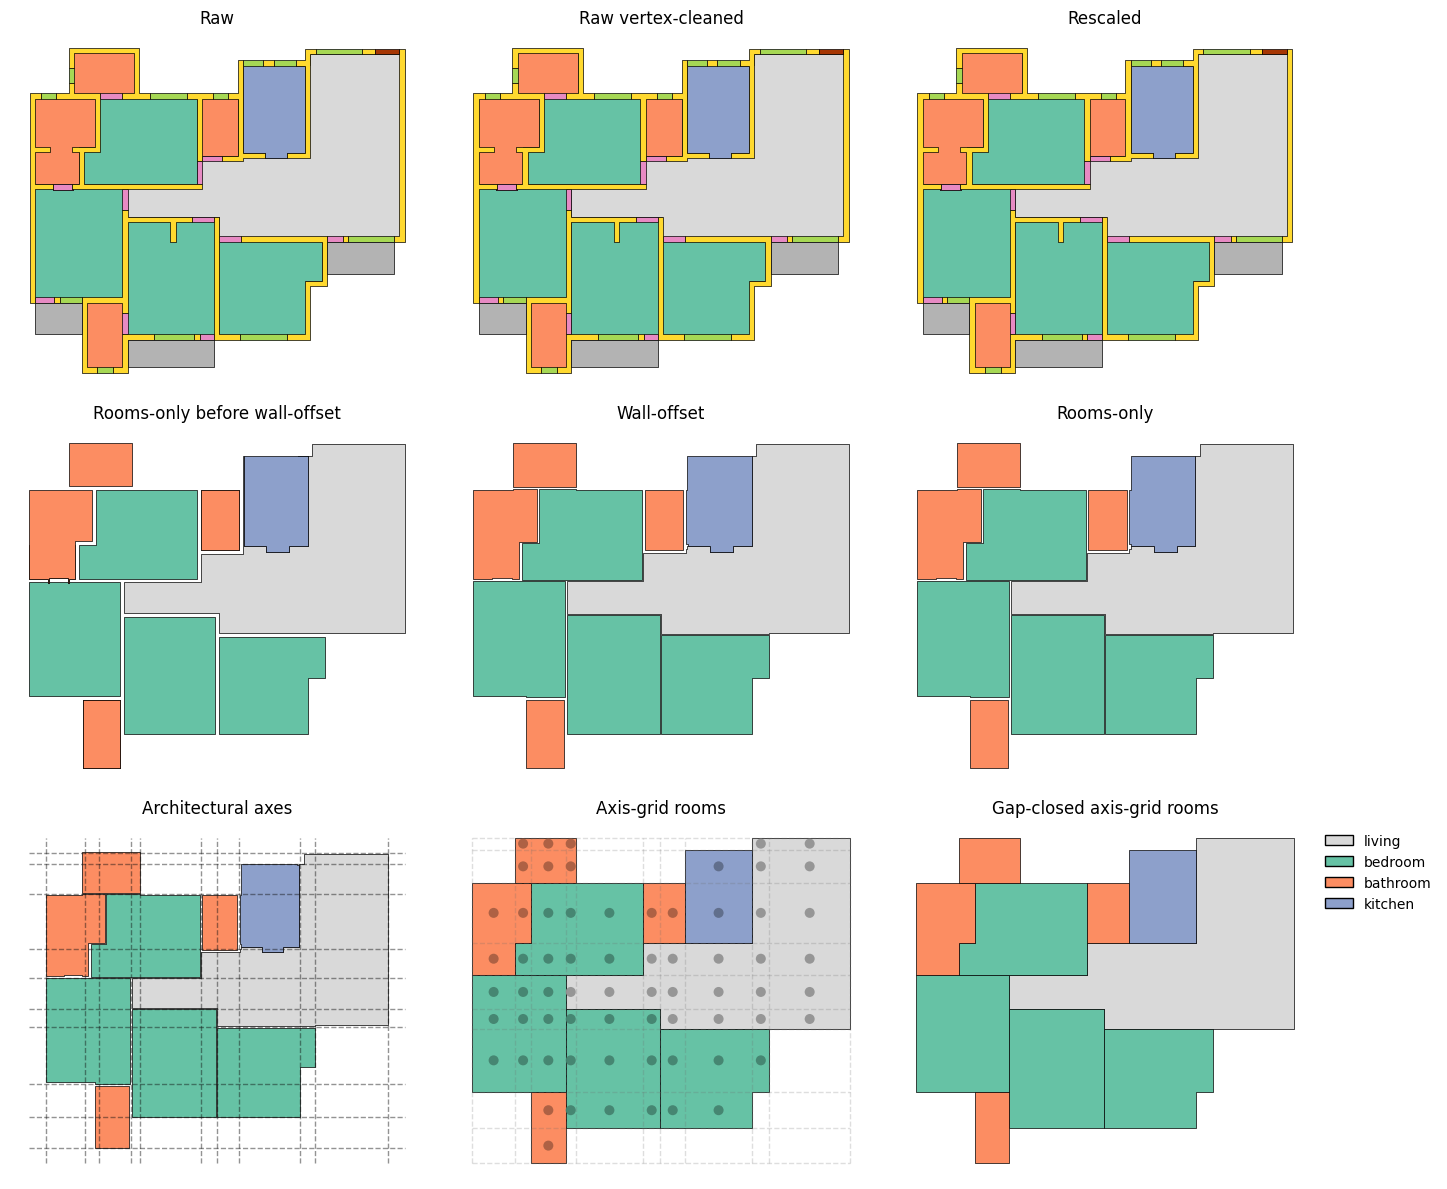

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_10171.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,17,137,39872.893735,13,NaN,NaN
1,Raw vertex-cleaned,17,137,39872.893735,13,NaN,NaN
2,Rescaled,17,137,231.033811,13,NaN,NaN
3,Rooms-only before wall-offset,17,137,231.033811,13,NaN,NaN
4,Wall-offset,13,168,226.713563,12,NaN,NaN
5,Rooms-only,13,168,226.713563,12,NaN,NaN
6,Architectural axes,11,152,226.233475,10,9.0,12.0
7,Axis-grid rooms,11,81,233.480581,6,NaN,NaN
8,Gap-closed axis-grid rooms,11,81,233.480581,6,NaN,NaN


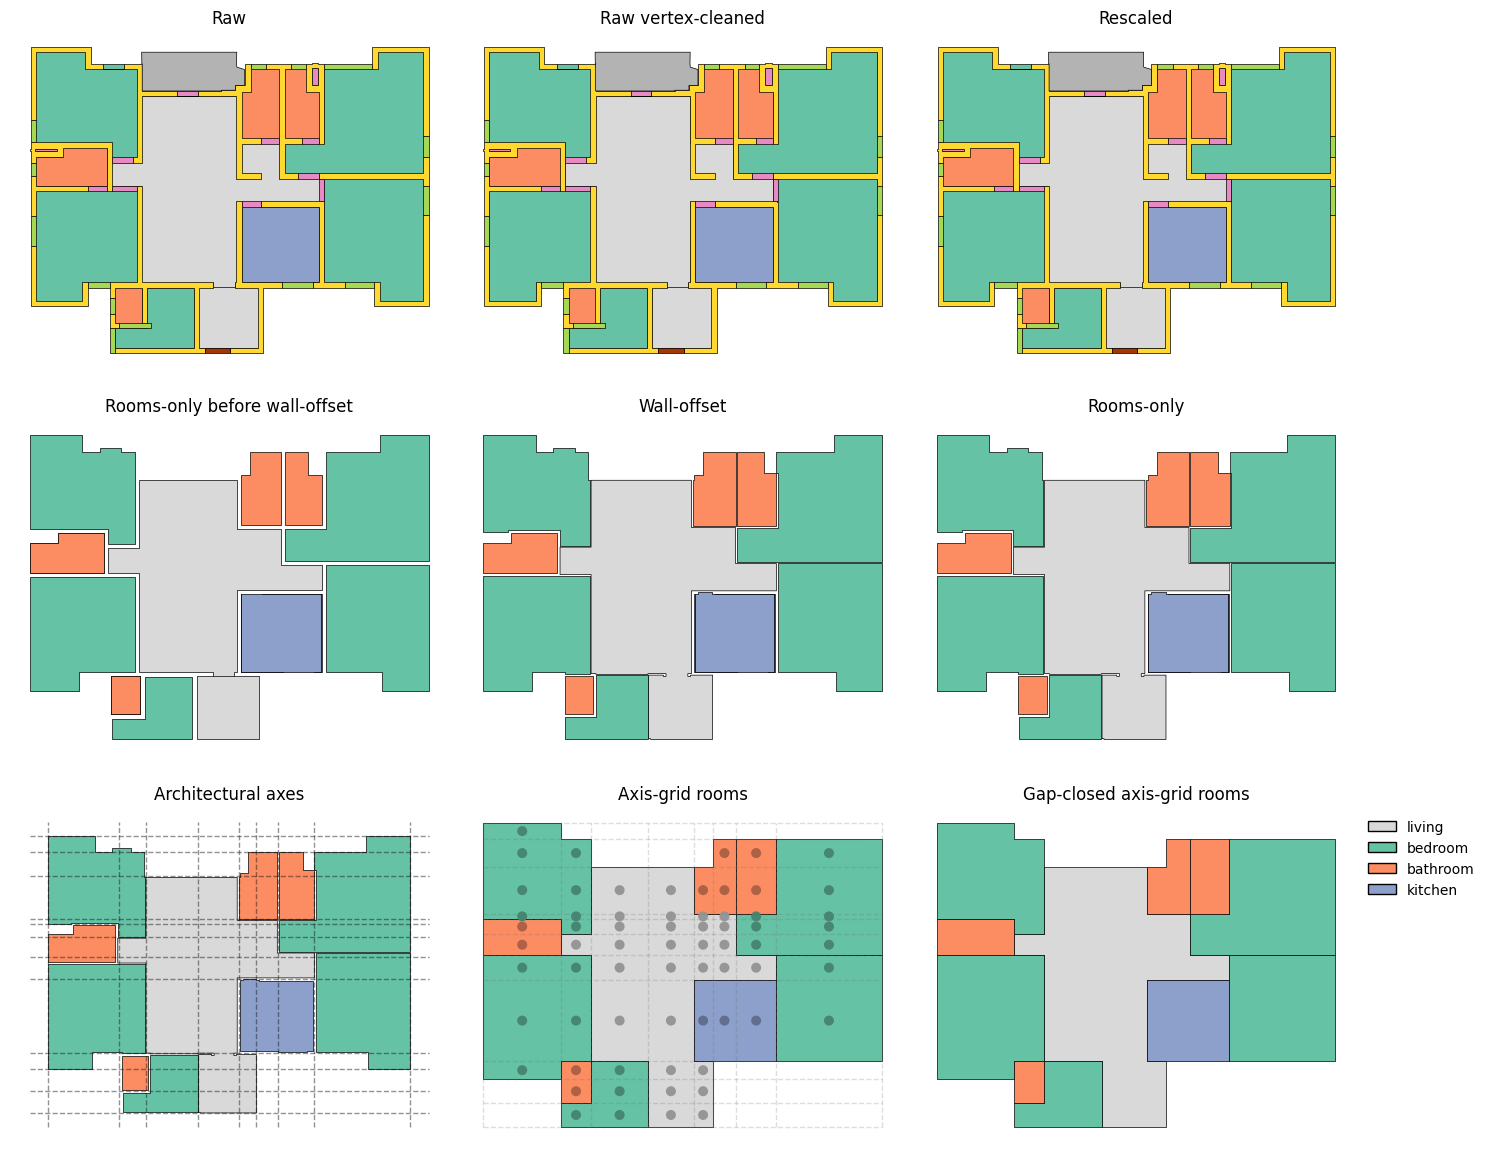

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_13737.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,12,96,29606.880330,11,NaN,NaN
1,Raw vertex-cleaned,12,96,29606.880330,11,NaN,NaN
2,Rescaled,12,96,166.757468,11,NaN,NaN
3,Rooms-only before wall-offset,12,96,166.757468,11,NaN,NaN
4,Wall-offset,11,132,165.261231,11,NaN,NaN
5,Rooms-only,11,132,165.261231,11,NaN,NaN
6,Architectural axes,9,116,164.800935,9,9.0,9.0
7,Axis-grid rooms,9,61,165.953224,4,NaN,NaN
8,Gap-closed axis-grid rooms,9,61,165.953224,4,NaN,NaN


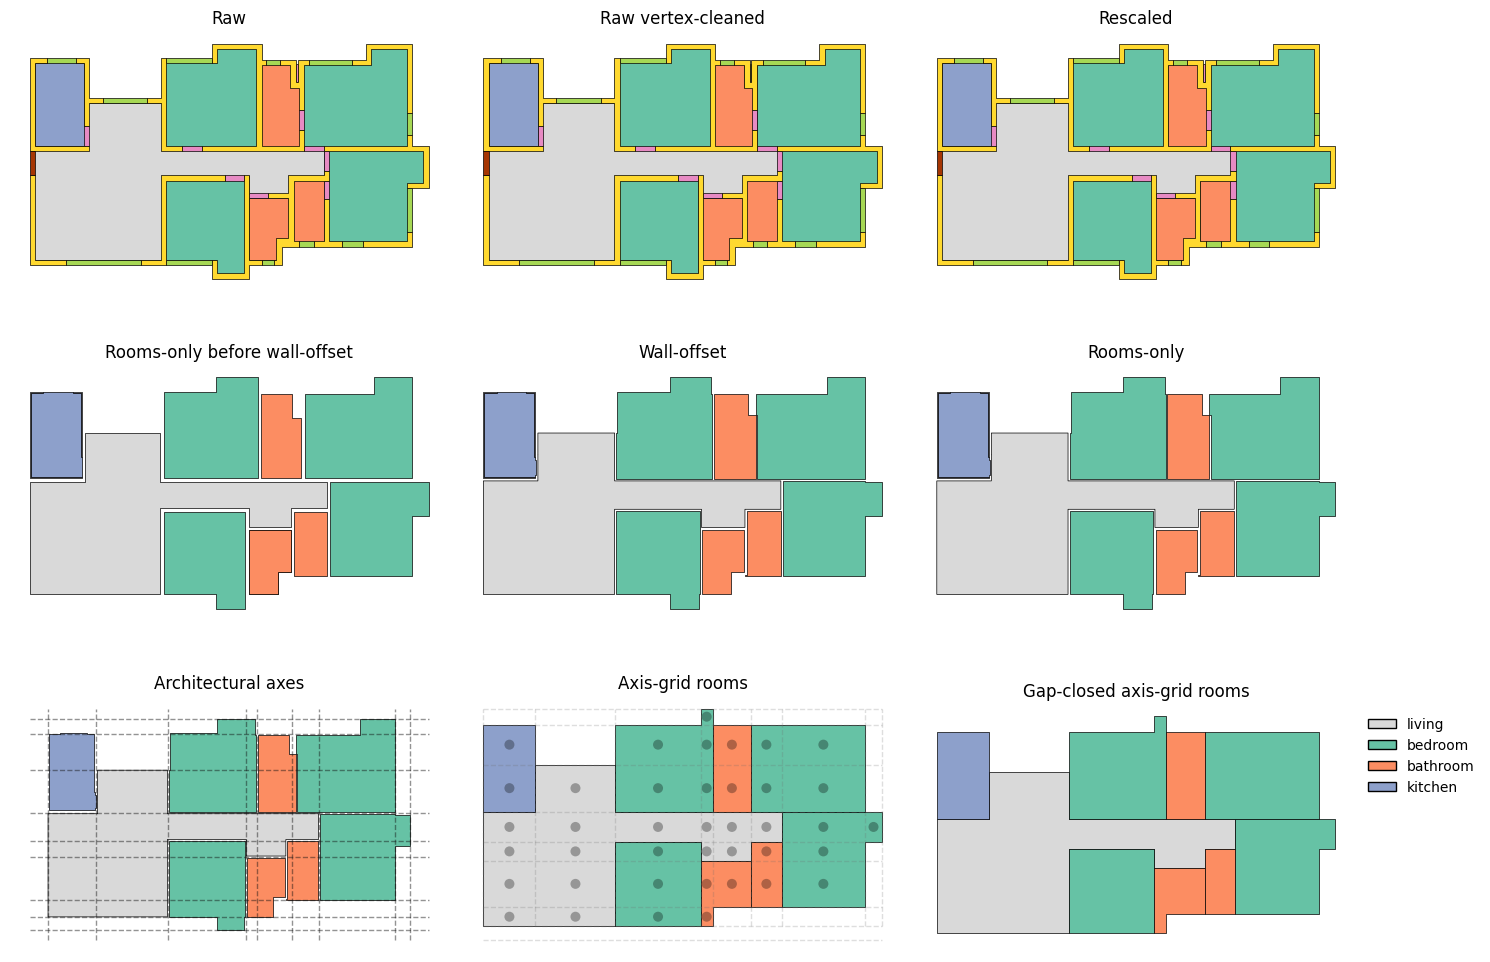

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_12600.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,7,79,21741.431188,5,NaN,NaN
1,Raw vertex-cleaned,7,79,21741.431188,5,NaN,NaN
2,Rescaled,7,79,113.242676,5,NaN,NaN
3,Rooms-only before wall-offset,7,79,113.242676,5,NaN,NaN
4,Wall-offset,7,93,115.406572,6,NaN,NaN
5,Rooms-only,7,93,115.406572,6,NaN,NaN
6,Architectural axes,6,86,115.318228,5,10.0,8.0
7,Axis-grid rooms,6,44,114.570115,3,NaN,NaN
8,Gap-closed axis-grid rooms,6,44,115.141925,3,NaN,NaN


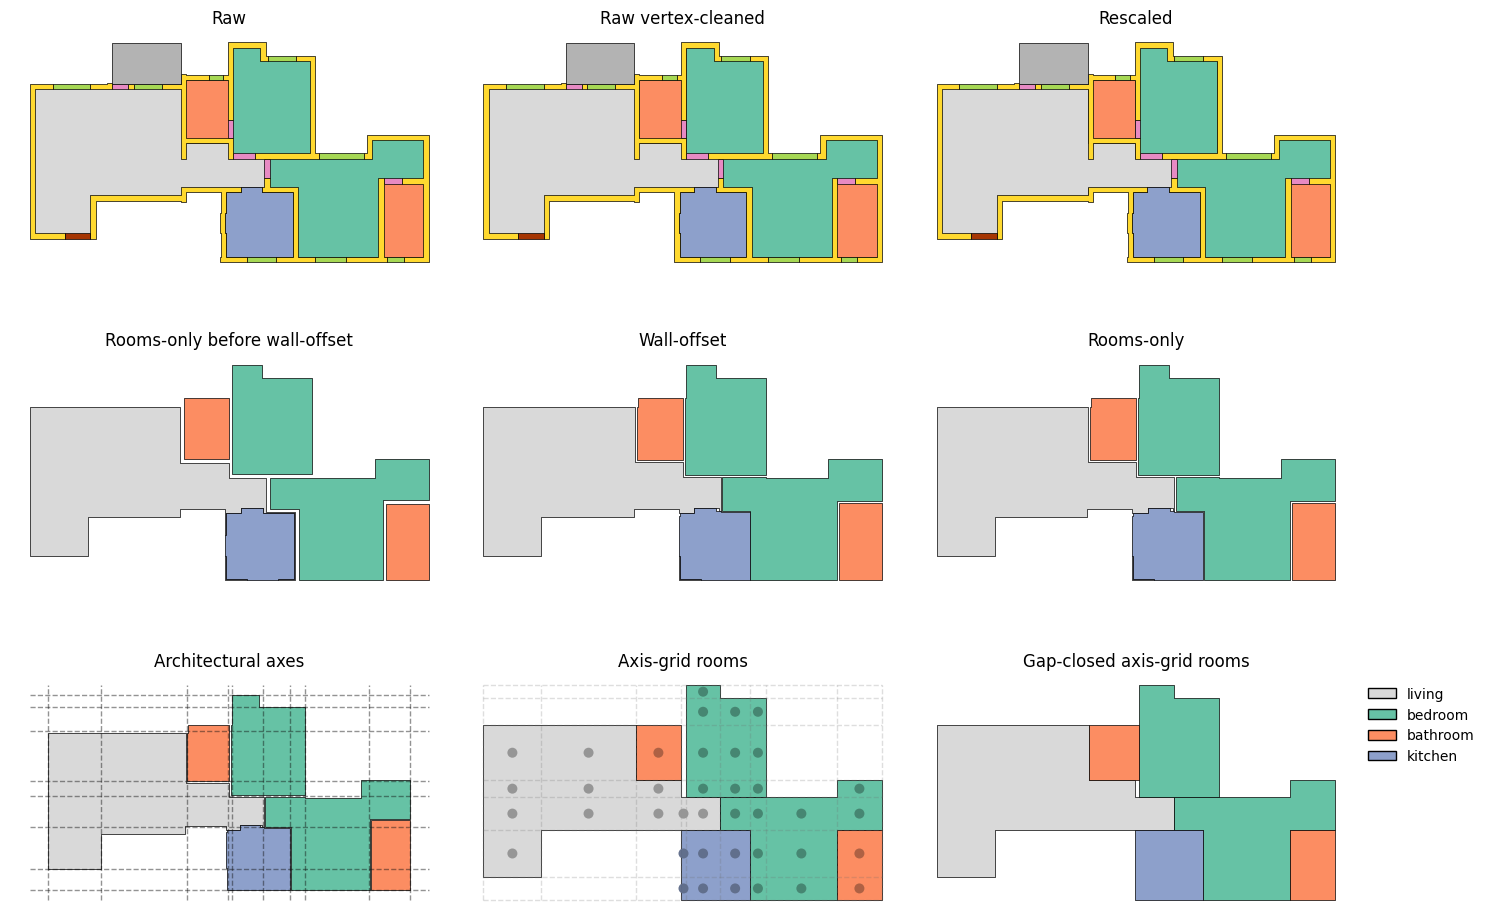

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_14035.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,10,82,34641.139119,5,NaN,NaN
1,Raw vertex-cleaned,10,82,34641.139119,5,NaN,NaN
2,Rescaled,10,82,188.245809,5,NaN,NaN
3,Rooms-only before wall-offset,10,82,188.245809,5,NaN,NaN
4,Wall-offset,9,102,186.379994,6,NaN,NaN
5,Rooms-only,9,102,186.379994,6,NaN,NaN
6,Architectural axes,8,97,184.491439,6,9.0,9.0
7,Axis-grid rooms,8,50,185.891740,3,NaN,NaN
8,Gap-closed axis-grid rooms,8,50,185.891740,3,NaN,NaN


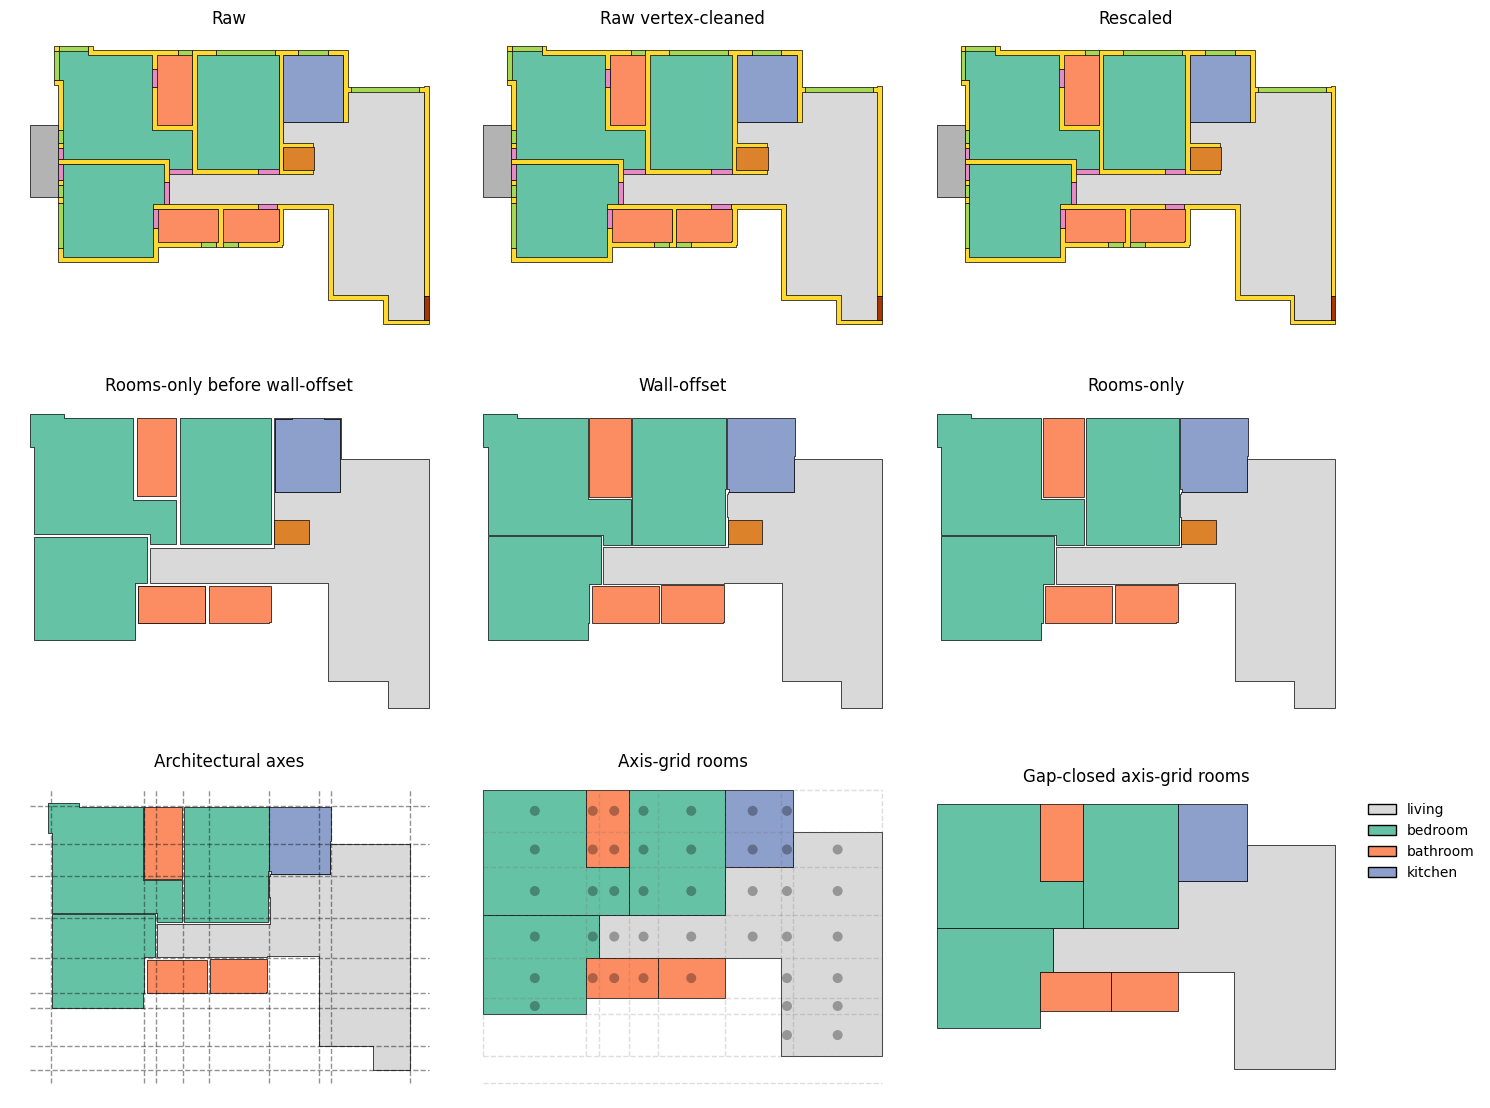

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_3467.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,6,62,34611.943845,3,NaN,NaN
1,Raw vertex-cleaned,6,62,34611.943845,3,NaN,NaN
2,Rescaled,6,62,107.442221,3,NaN,NaN
3,Rooms-only before wall-offset,6,62,107.442221,3,NaN,NaN
4,Wall-offset,6,89,109.547925,5,NaN,NaN
5,Rooms-only,6,89,109.547925,5,NaN,NaN
6,Architectural axes,6,89,109.547925,5,7.0,8.0
7,Axis-grid rooms,6,40,111.284158,3,NaN,NaN
8,Gap-closed axis-grid rooms,6,40,111.284158,3,NaN,NaN


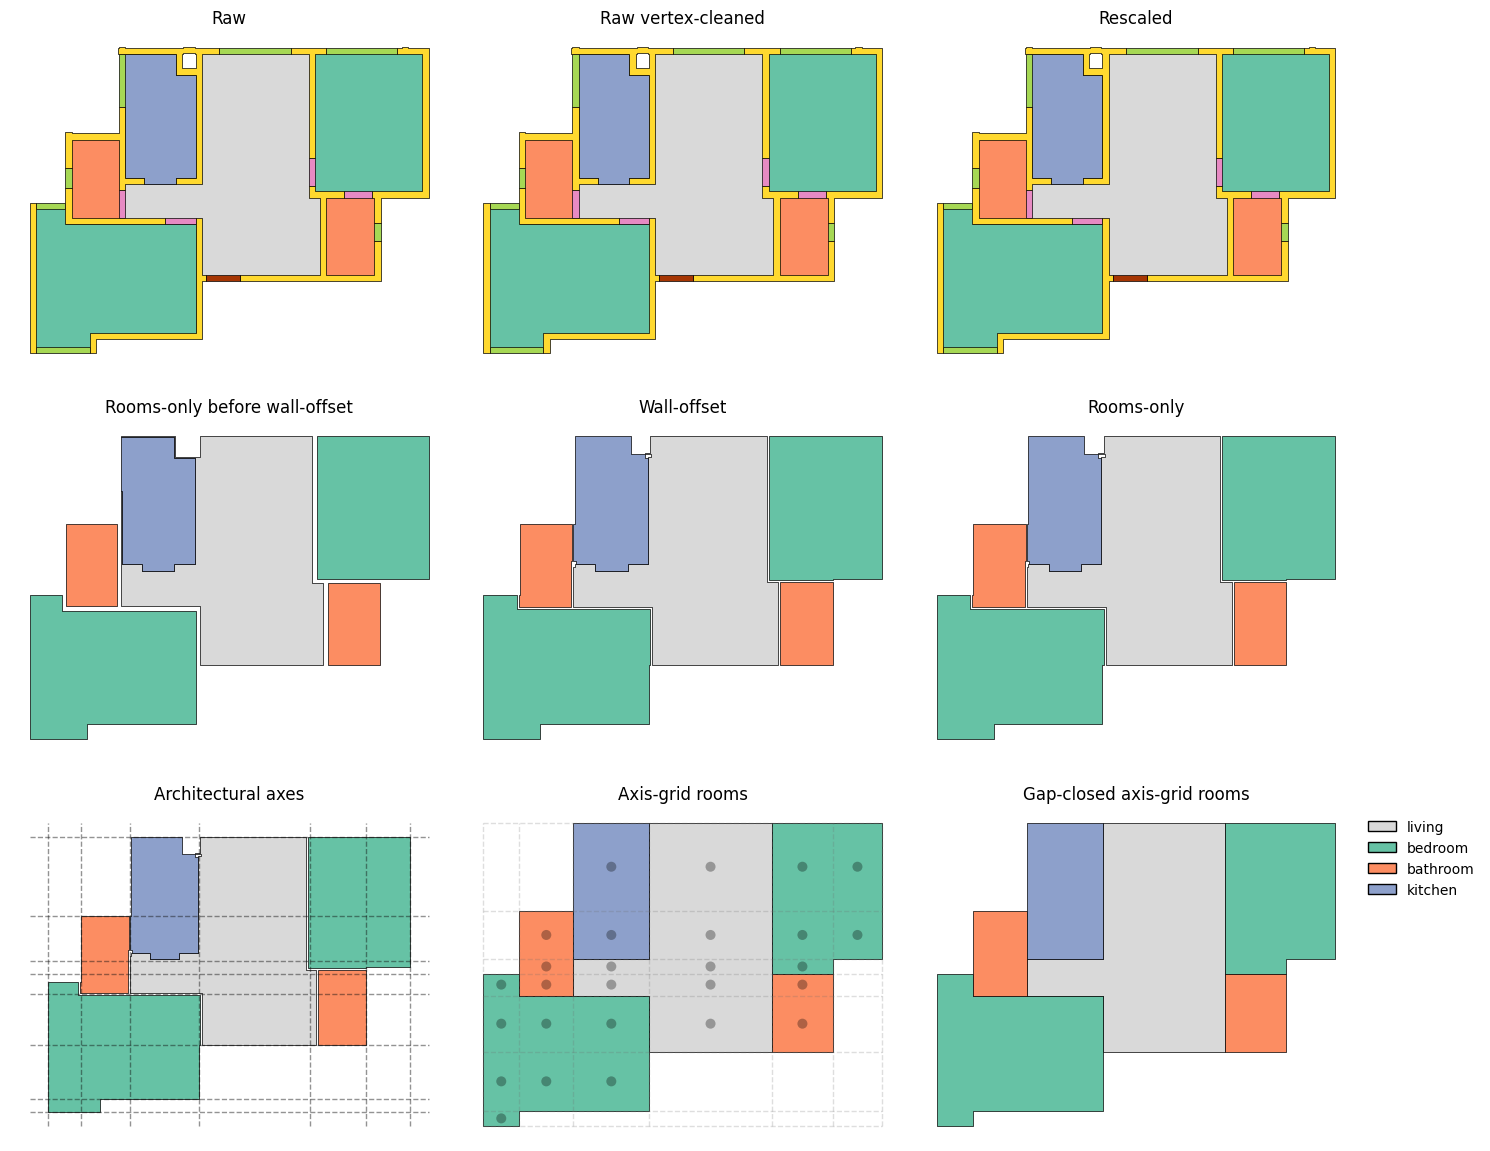

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_4625.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,6,50,27726.858134,4,NaN,NaN
1,Raw vertex-cleaned,6,50,27726.858134,4,NaN,NaN
2,Rescaled,6,50,179.473338,4,NaN,NaN
3,Rooms-only before wall-offset,6,50,179.473338,4,NaN,NaN
4,Wall-offset,6,72,181.935871,5,NaN,NaN
5,Rooms-only,6,72,181.935871,5,NaN,NaN
6,Architectural axes,6,72,181.935871,5,10.0,9.0
7,Axis-grid rooms,6,40,185.947249,3,NaN,NaN
8,Gap-closed axis-grid rooms,6,40,185.947249,3,NaN,NaN


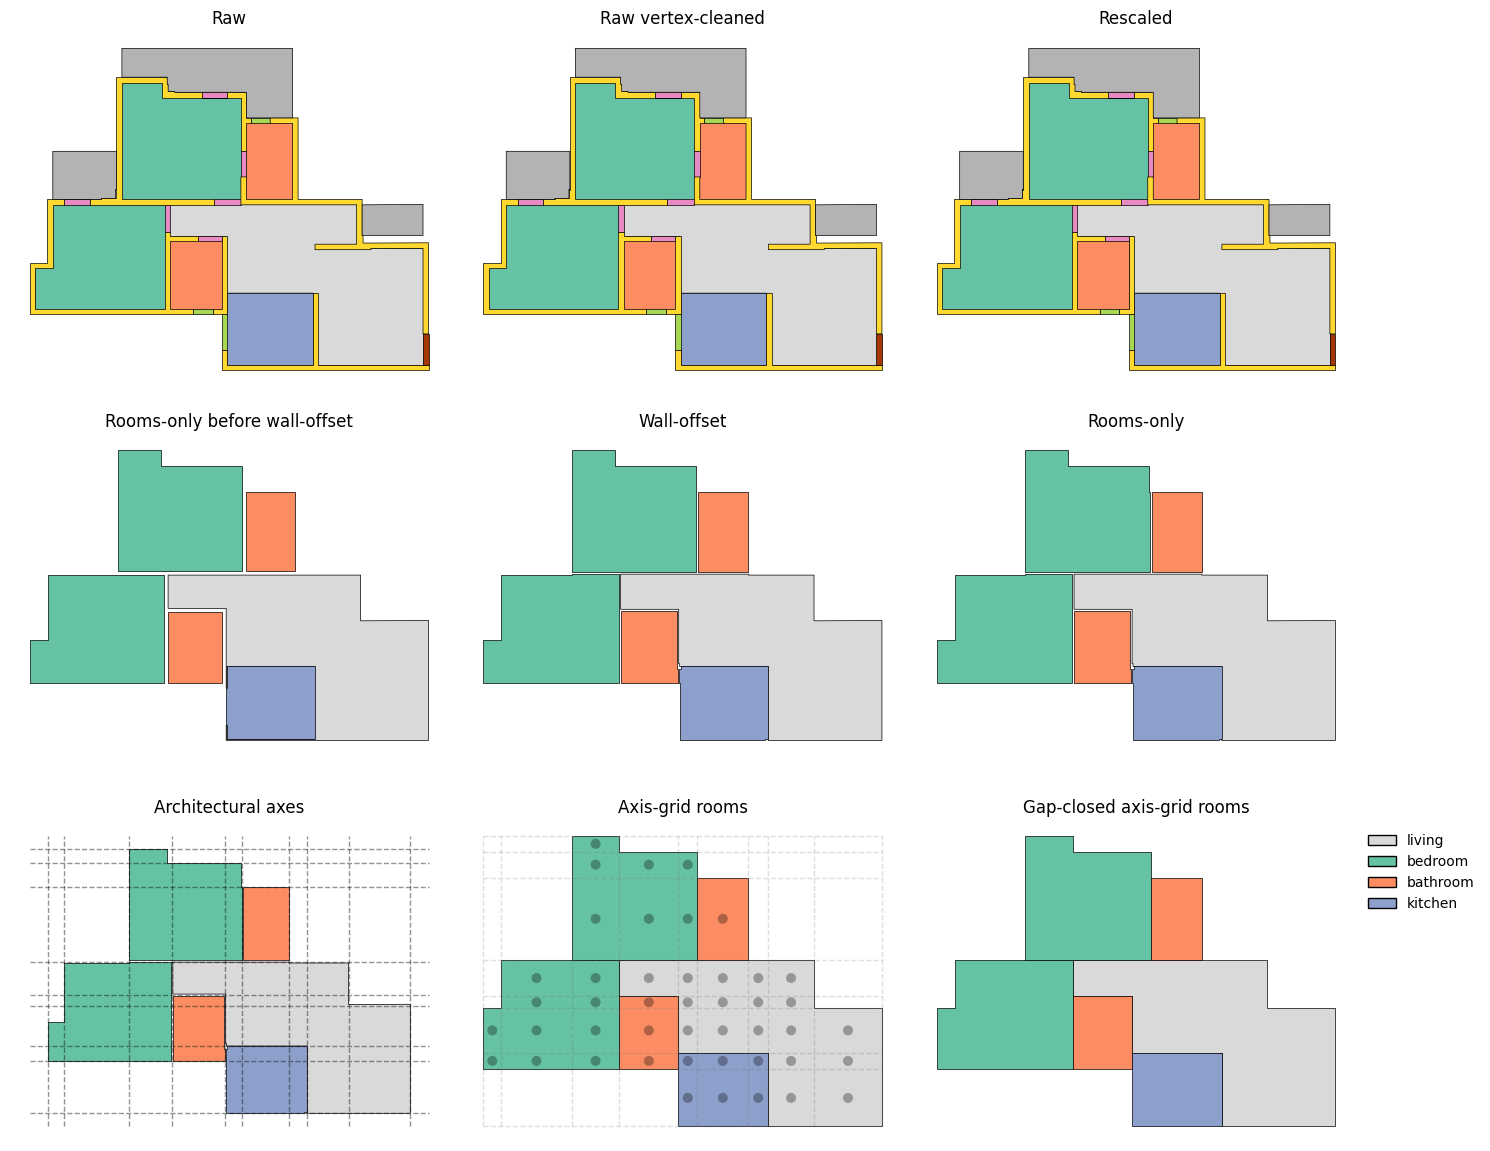

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_3796.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,14,114,32442.960418,5,NaN,NaN
1,Raw vertex-cleaned,14,111,32442.960376,5,NaN,NaN
2,Rescaled,14,111,197.915203,5,NaN,NaN
3,Rooms-only before wall-offset,14,111,197.915203,5,NaN,NaN
4,Wall-offset,9,99,182.151051,7,NaN,NaN
5,Rooms-only,9,99,182.151051,7,NaN,NaN
6,Architectural axes,9,99,182.151051,7,11.0,8.0
7,Axis-grid rooms,9,55,188.544622,3,NaN,NaN
8,Gap-closed axis-grid rooms,9,55,188.544622,3,NaN,NaN


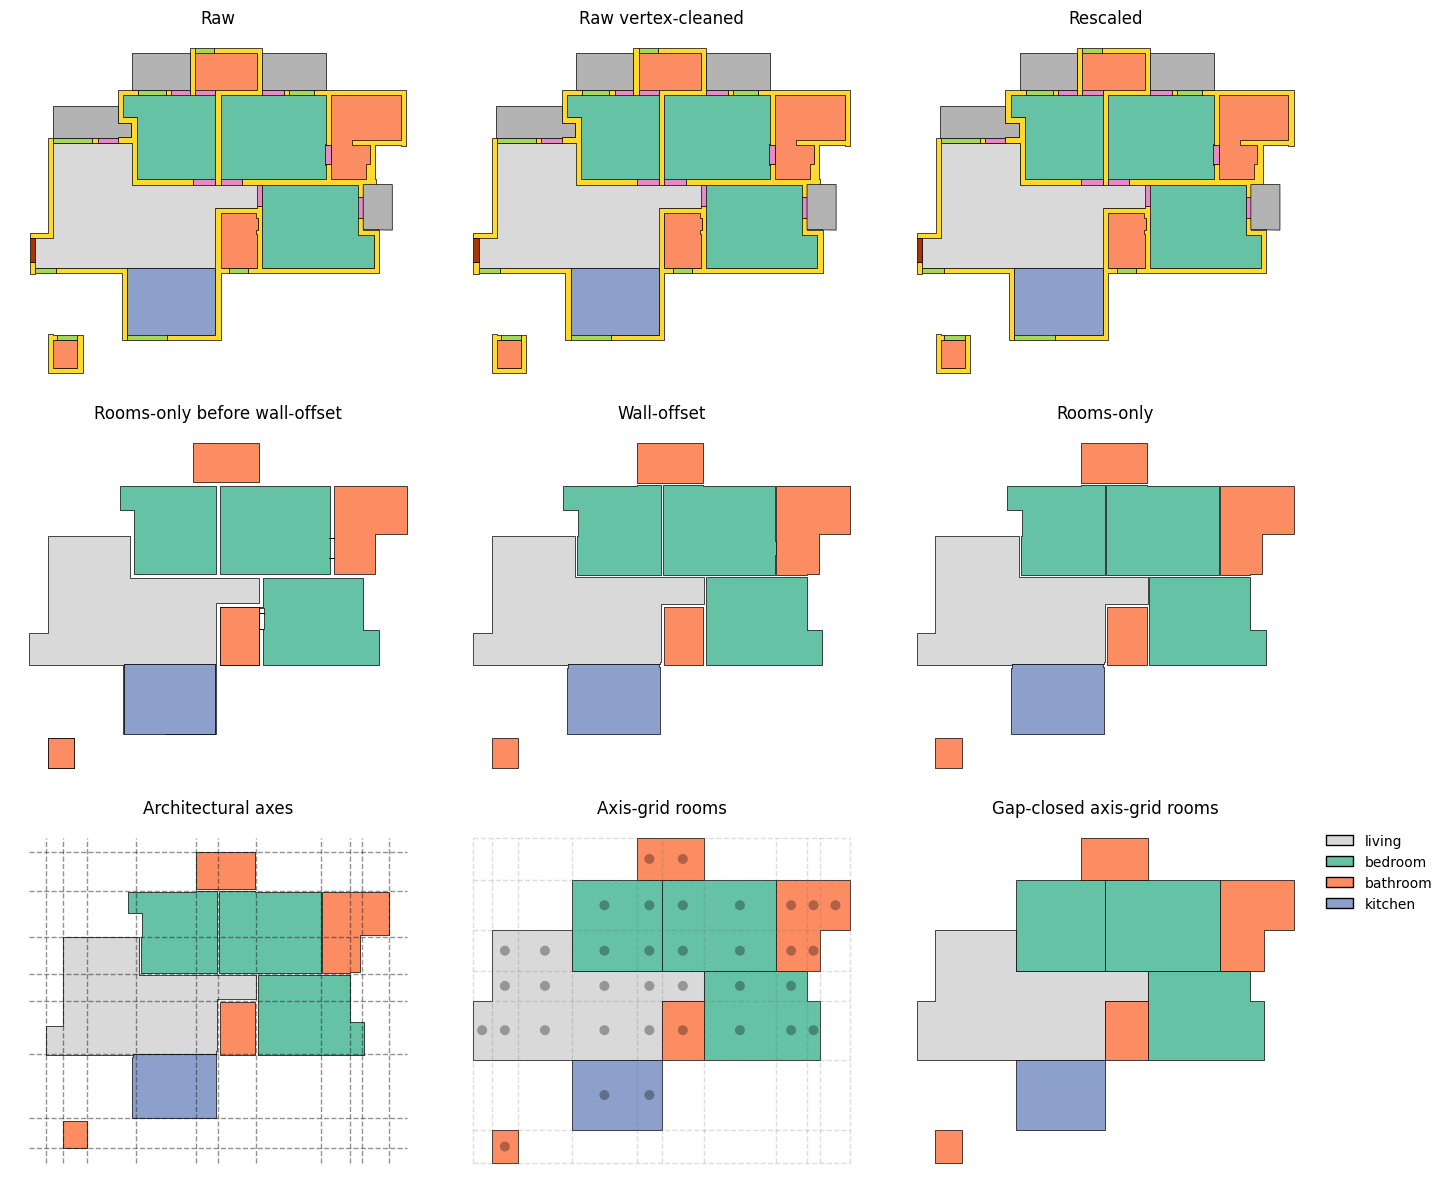

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_704238.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,11,91,26304.215316,7,NaN,NaN
1,Raw vertex-cleaned,11,91,26304.215316,7,NaN,NaN
2,Rescaled,11,91,180.406089,7,NaN,NaN
3,Rooms-only before wall-offset,11,91,180.406089,7,NaN,NaN
4,Wall-offset,10,126,178.232765,8,NaN,NaN
5,Rooms-only,10,126,178.232765,8,NaN,NaN
6,Architectural axes,10,126,178.232765,8,13.0,11.0
7,Axis-grid rooms,10,62,184.394799,3,NaN,NaN
8,Gap-closed axis-grid rooms,10,62,184.394799,3,NaN,NaN


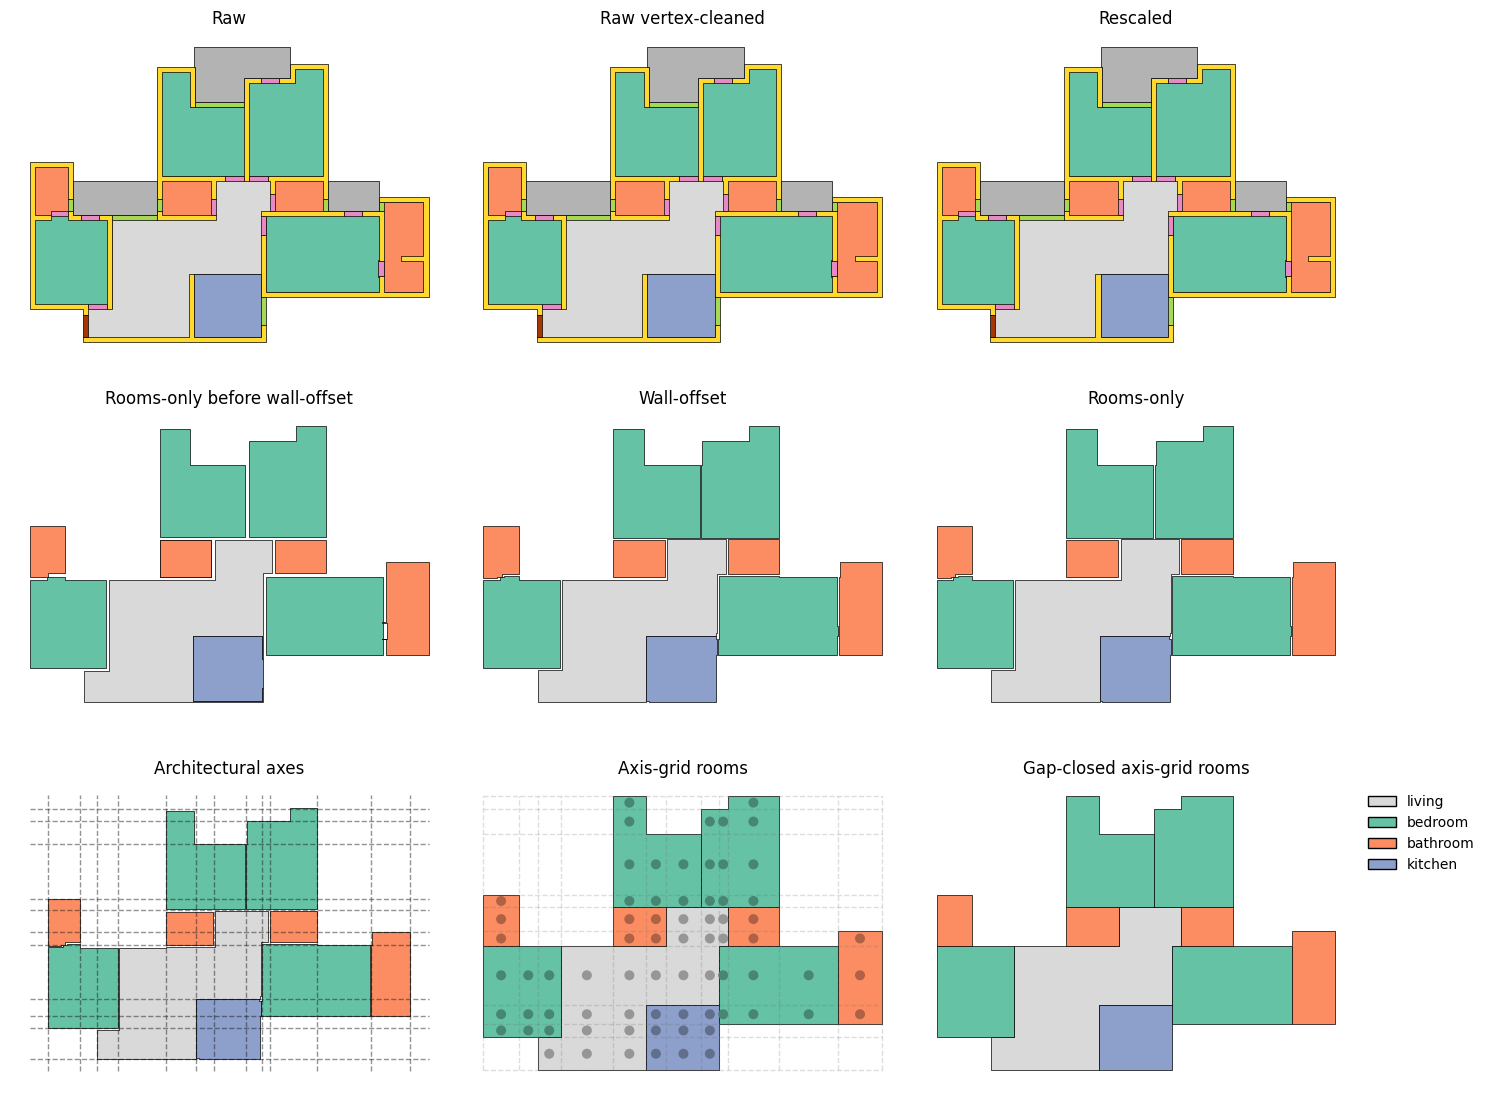

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_3807.svg


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,6,40,31555.336598,4,NaN,NaN
1,Raw vertex-cleaned,6,40,31555.336598,4,NaN,NaN
2,Rescaled,6,40,97.756709,4,NaN,NaN
3,Rooms-only before wall-offset,6,40,97.756709,4,NaN,NaN
4,Wall-offset,6,67,98.761318,5,NaN,NaN
5,Rooms-only,6,67,98.761318,5,NaN,NaN
6,Architectural axes,6,67,98.761318,5,6.0,6.0
7,Axis-grid rooms,6,38,100.427941,3,NaN,NaN
8,Gap-closed axis-grid rooms,6,38,100.427941,3,NaN,NaN


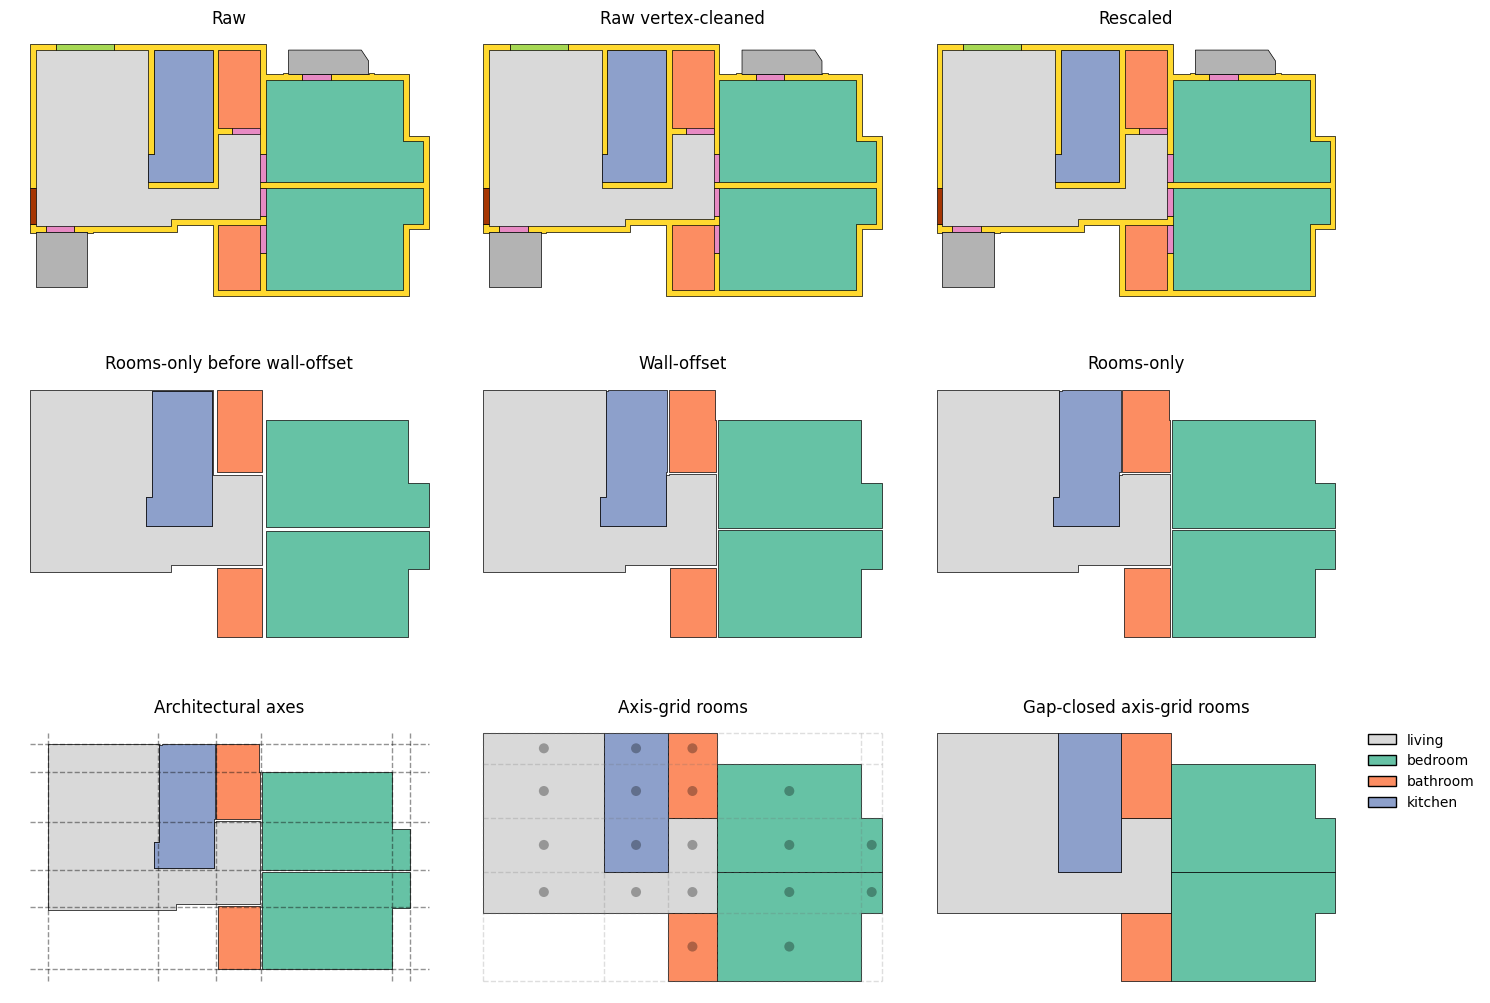

Saved preprocessing showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_steps_selected/steps_overview_5549.svg


In [16]:
SVG_DIR = NOTEBOOK_OUTPUT_DIR / "svg_steps_selected"
SVG_DIR.mkdir(parents=True, exist_ok=True)


def _plan_lookup(plans):
    return {plan.get("id"): plan for plan in plans}


def _room_vertex_count_for_plan(plan):
    return sum(len(list(poly.exterior.coords)) for poly in plan_room_polygons(plan, ROOM_KEYS))


def _room_area_for_plan(plan):
    return float(sum(poly.area for poly in plan_room_polygons(plan, ROOM_KEYS)))


def _concave_room_count_for_plan(plan):
    return concave_polygon_count(plan_room_polygons(plan, ROOM_KEYS))


def _plot_plan_or_axes(ax, stage_name, plan, axis_info=None, axis_grid_metrics=None, show_legend=False):
    if axis_info is not None and axis_grid_metrics is not None:
        plot_axis_grid_rooms(ax, plan, axis_info, axis_grid_metrics, legend=show_legend, title=stage_name)
    else:
        plot_plan(plan, ax=ax, legend=show_legend, title=stage_name)
        if axis_info is not None:
            _draw_cluster_axes(ax, axis_info["clusters_after"], _plan_bounds(plan), axis_info["orthogonal_only"])
        ax.set_axis_off()


final_selected_lookup = _plan_lookup(floorplans_rooms_axis_grid)
pre_gap_lookup = dict(axis_grid_showcase_before_gap_cleanup)
requested_showcase_count = max(0, int(SHOWCASE_PLAN_COUNT))
showcase_ids = [pid for pid in SHOWCASE_PLAN_IDS if pid in final_selected_lookup]
if len(showcase_ids) < requested_showcase_count:
    fallback_ids = [pid for pid in final_selected_lookup if pid not in showcase_ids]
    showcase_ids.extend(fallback_ids[: max(0, requested_showcase_count - len(showcase_ids))])
else:
    showcase_ids = showcase_ids[:requested_showcase_count]

if not showcase_ids:
    print("[Error] No final selected showcase plans are available.")
else:
    raw_lookup = _plan_lookup(floorplans_all_raw)
    raw_clean_lookup = _plan_lookup(floorplans_all)
    rescaled_lookup = _plan_lookup(rescaled_floorplans)
    wall_offset_lookup = _plan_lookup(room_offset_floorplans)
    rooms_lookup = _plan_lookup(floorplans_rooms)
    split_lookup = _plan_lookup(floorplans_rooms_split)
    pre_min_area_lookup = _plan_lookup(floorplans_rooms_axis_grid_all)

    for target_id in showcase_ids:
        rescaled_plan = rescaled_lookup.get(target_id)
        room_offset_plan = wall_offset_lookup.get(target_id)
        rooms_before = _keep_room_layers([rescaled_plan])[0] if rescaled_plan is not None else None

        step_entries = [
            ("Raw", raw_lookup.get(target_id), None, None),
            ("Raw vertex-cleaned", raw_clean_lookup.get(target_id), None, None),
            ("Rescaled", rescaled_plan, None, None),
            ("Rooms-only before wall-offset", rooms_before, None, None),
            ("Wall-offset", room_offset_plan, None, None),
            ("Rooms-only", rooms_lookup.get(target_id), None, None),
        ]

        axis_info = floorplan_axes_by_id.get(target_id)
        step_entries.extend([
            ("Architectural axes", split_lookup.get(target_id), axis_info, None),
            ("Axis-grid rooms", pre_gap_lookup.get(target_id), axis_info, axis_grid_metrics_by_id.get(target_id)),
            ("Gap-closed axis-grid rooms", pre_min_area_lookup.get(target_id), None, None),
        ])

        step_rows = []
        for stage_name, plan, stage_axis_info, _stage_grid_metrics in step_entries:
            if plan is None:
                continue
            room_polys = plan_room_polygons(plan, ROOM_KEYS)
            row = {
                "step": stage_name,
                "room_polygons": int(len(room_polys)),
                "vertices": int(_room_vertex_count_for_plan(plan)),
                "total_room_area_m2": float(_room_area_for_plan(plan)),
                "concave_rooms": int(_concave_room_count_for_plan(plan)),
                "vertical_axes": None,
                "horizontal_axes": None,
            }
            if stage_name == "Architectural axes" and stage_axis_info is not None:
                row["vertical_axes"] = int(sum(1 for c in stage_axis_info["clusters_after"] if c.get("family") == "vertical"))
                row["horizontal_axes"] = int(sum(1 for c in stage_axis_info["clusters_after"] if c.get("family") == "horizontal"))
            step_rows.append(row)

        display(pd.DataFrame(step_rows))

        ncols = 3
        nrows = int(math.ceil(len(step_entries) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = np.atleast_1d(axes).flatten()
        for idx, (stage_name, plan, stage_axis_info, stage_grid_metrics) in enumerate(step_entries):
            ax = axes[idx]
            if plan is None:
                ax.set_visible(False)
                continue
            _plot_plan_or_axes(ax, stage_name, plan, axis_info=stage_axis_info, axis_grid_metrics=stage_grid_metrics, show_legend=(idx == len(step_entries) - 1))
        for ax in axes[len(step_entries):]:
            ax.set_visible(False)
        plt.tight_layout()

        fig_path = SVG_DIR / f"steps_overview_{target_id}.svg"
        fig.savefig(fig_path, format="svg", bbox_inches="tight")
        plt.show()
        print(f"Saved preprocessing showcase SVG to {fig_path}")


### Diagnose target sliver cases
Inspect ids `4111`, `16228`, and `1491` stage by stage and flag the first transition where very low-compactness room pieces appear. This is meant to separate axis-grid reconstruction issues from narrow-gap cleanup artifacts before changing any global tolerances.

=== Targeted sliver diagnostics for id=4111 ===


,step,room_polygons,concave_rooms,vertices,min_room_area_m2,min_compactness,skinny_rooms,worst_room_label,vertical_axes,horizontal_axes
0,Raw vertex-cleaned,14,4,92,473.791772,0.215433,1,living,NaN,NaN
1,Rescaled,14,4,92,2.388543,0.215433,1,living,NaN,NaN
2,Rooms-only,11,8,120,2.388543,0.398016,1,living,NaN,NaN
3,Rooms split,11,8,120,2.388543,0.398016,1,living,NaN,NaN
4,Architectural axes,11,8,120,2.388543,0.398016,1,living,10.0,11.0
5,Axis-grid rooms,11,4,60,2.446711,0.415612,1,living,10.0,11.0
6,Gap-closed axis-grid rooms,11,4,60,2.446711,0.415612,1,living,NaN,NaN
7,Final selected,11,4,60,2.446711,0.415612,1,living,NaN,NaN


First suspicious transition: Rooms-only (compactness drop -0.18, skinny-room change +0, vertex change +28). Likely introduced before the final axis-grid cleanup stages.


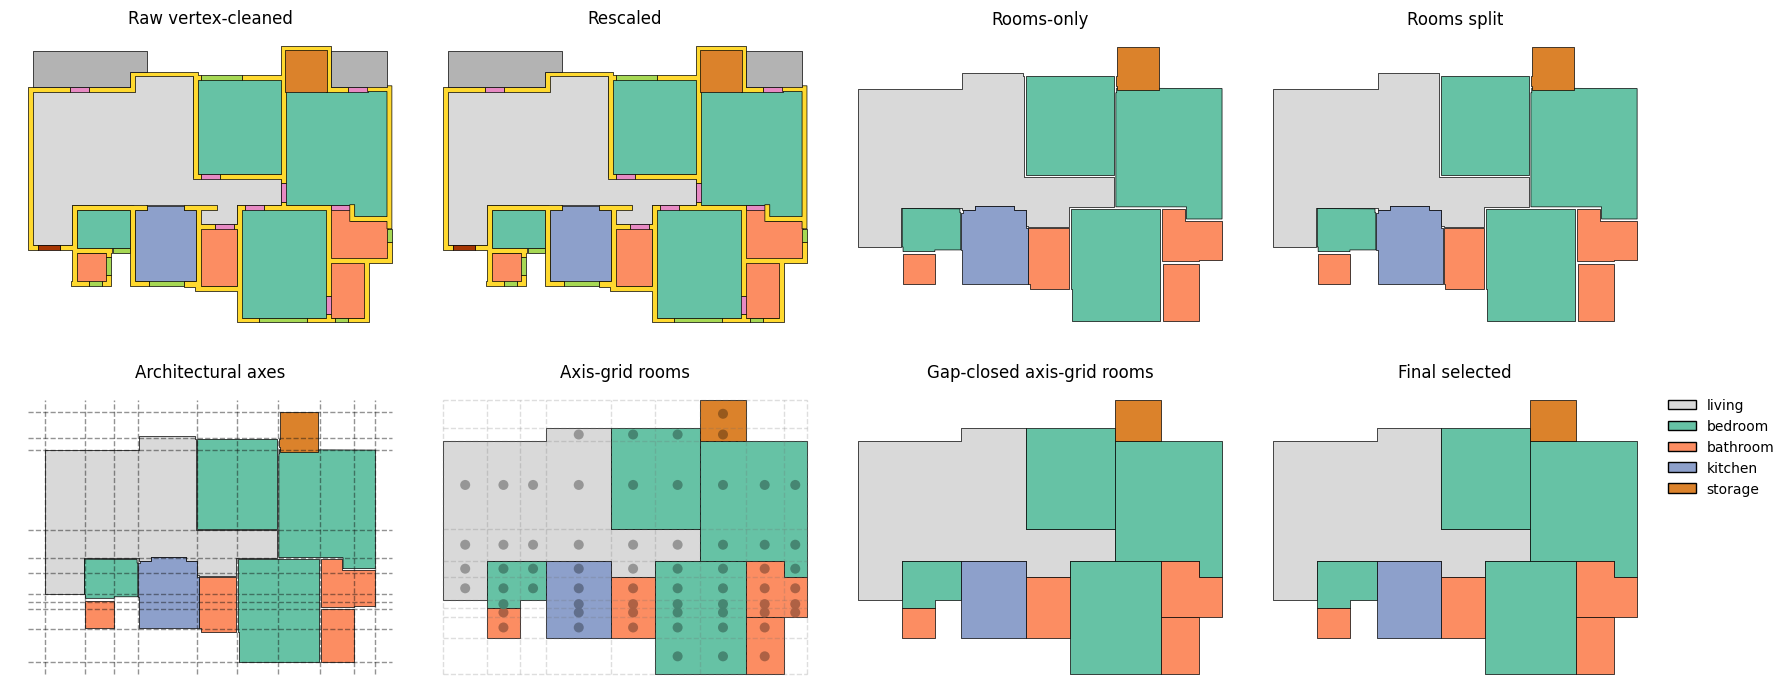

=== Targeted sliver diagnostics for id=16228 ===


,step,room_polygons,concave_rooms,vertices,min_room_area_m2,min_compactness,skinny_rooms,worst_room_label,vertical_axes,horizontal_axes
0,Raw vertex-cleaned,13,6,104,48.162854,0.016514,2,living,NaN,NaN
1,Rescaled,13,6,104,0.205162,0.016514,2,living,NaN,NaN
2,Rooms-only,11,7,132,0.205162,0.016514,2,living,NaN,NaN
3,Rooms split,10,6,126,5.202335,0.325394,1,living,NaN,NaN
4,Architectural axes,10,6,126,5.202335,0.325394,1,living,10.0,9.0
5,Axis-grid rooms,10,4,54,5.167466,0.439343,1,living,10.0,9.0
6,Gap-closed axis-grid rooms,10,4,54,5.167466,0.439343,1,living,NaN,NaN
7,Final selected,10,4,54,5.167466,0.439343,1,living,NaN,NaN


First suspicious transition: Rooms-only (compactness drop -0.00, skinny-room change +0, vertex change +28). Likely introduced before the final axis-grid cleanup stages.


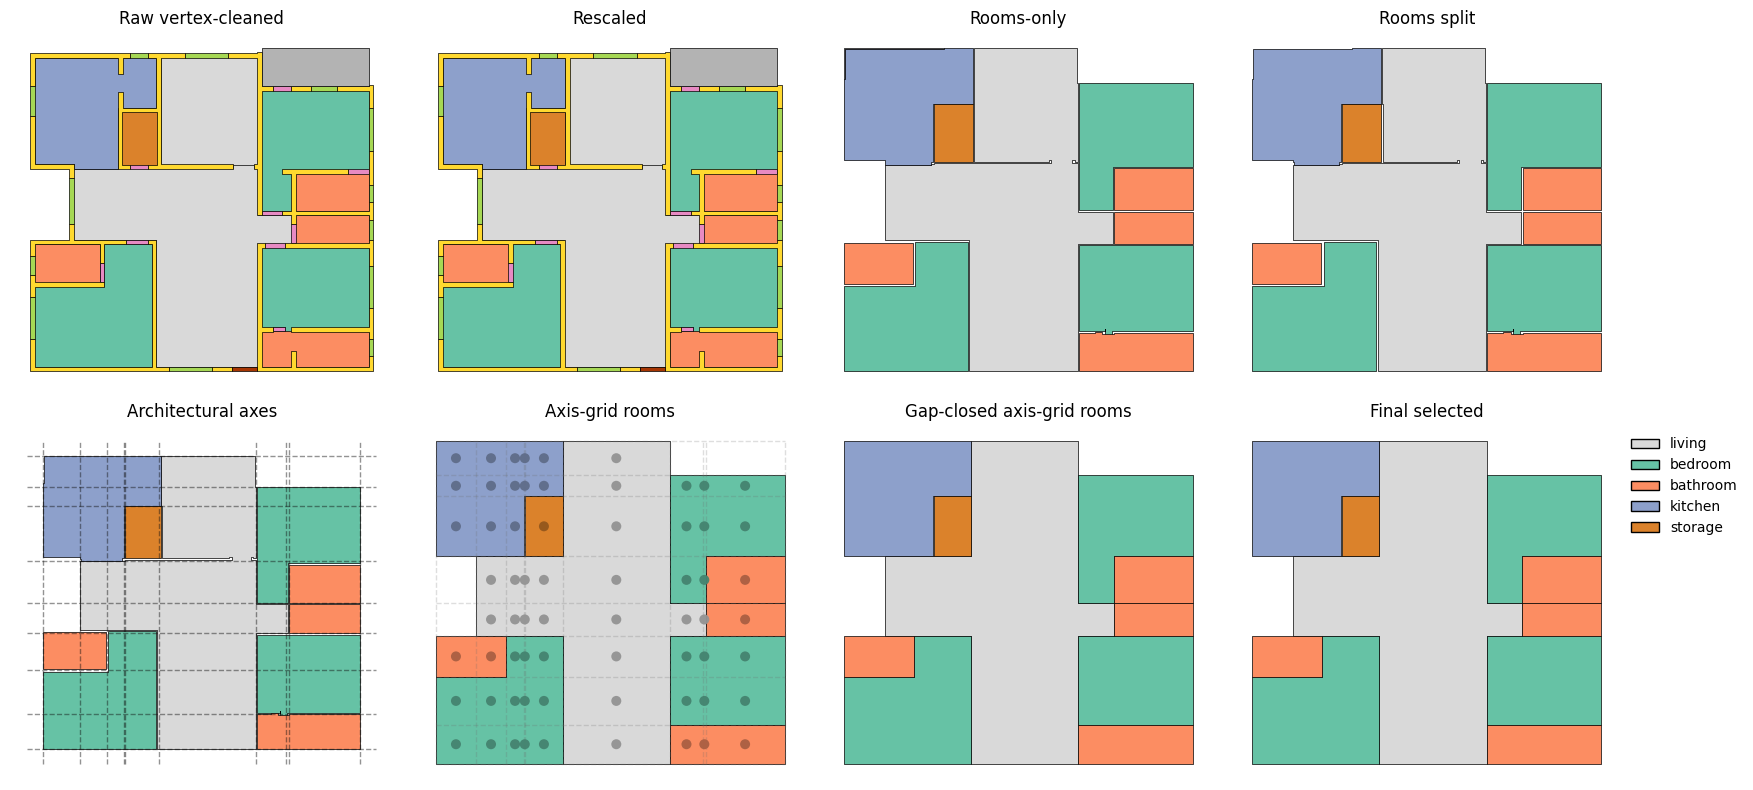

=== Targeted sliver diagnostics for id=1491 ===


,step,room_polygons,concave_rooms,vertices,min_room_area_m2,min_compactness,skinny_rooms,worst_room_label,vertical_axes,horizontal_axes
0,Raw vertex-cleaned,10,7,60,44.167851,0.017766,2,living,NaN,NaN
1,Rescaled,10,7,60,0.147139,0.017766,2,living,NaN,NaN
2,Rooms-only,9,8,87,0.147139,0.017766,2,living,NaN,NaN
3,Rooms split,7,6,73,5.891792,0.643476,0,bathroom,NaN,NaN
4,Architectural axes,7,6,73,5.891792,0.643476,0,bathroom,8.0,8.0
5,Axis-grid rooms,7,3,34,6.381924,0.645615,0,bathroom,8.0,8.0
6,Gap-closed axis-grid rooms,7,3,34,6.381924,0.645615,0,bathroom,NaN,NaN
7,Final selected,7,3,34,6.381924,0.645615,0,bathroom,NaN,NaN


First suspicious transition: Rooms-only (compactness drop +0.00, skinny-room change +0, vertex change +27). Likely introduced before the final axis-grid cleanup stages.


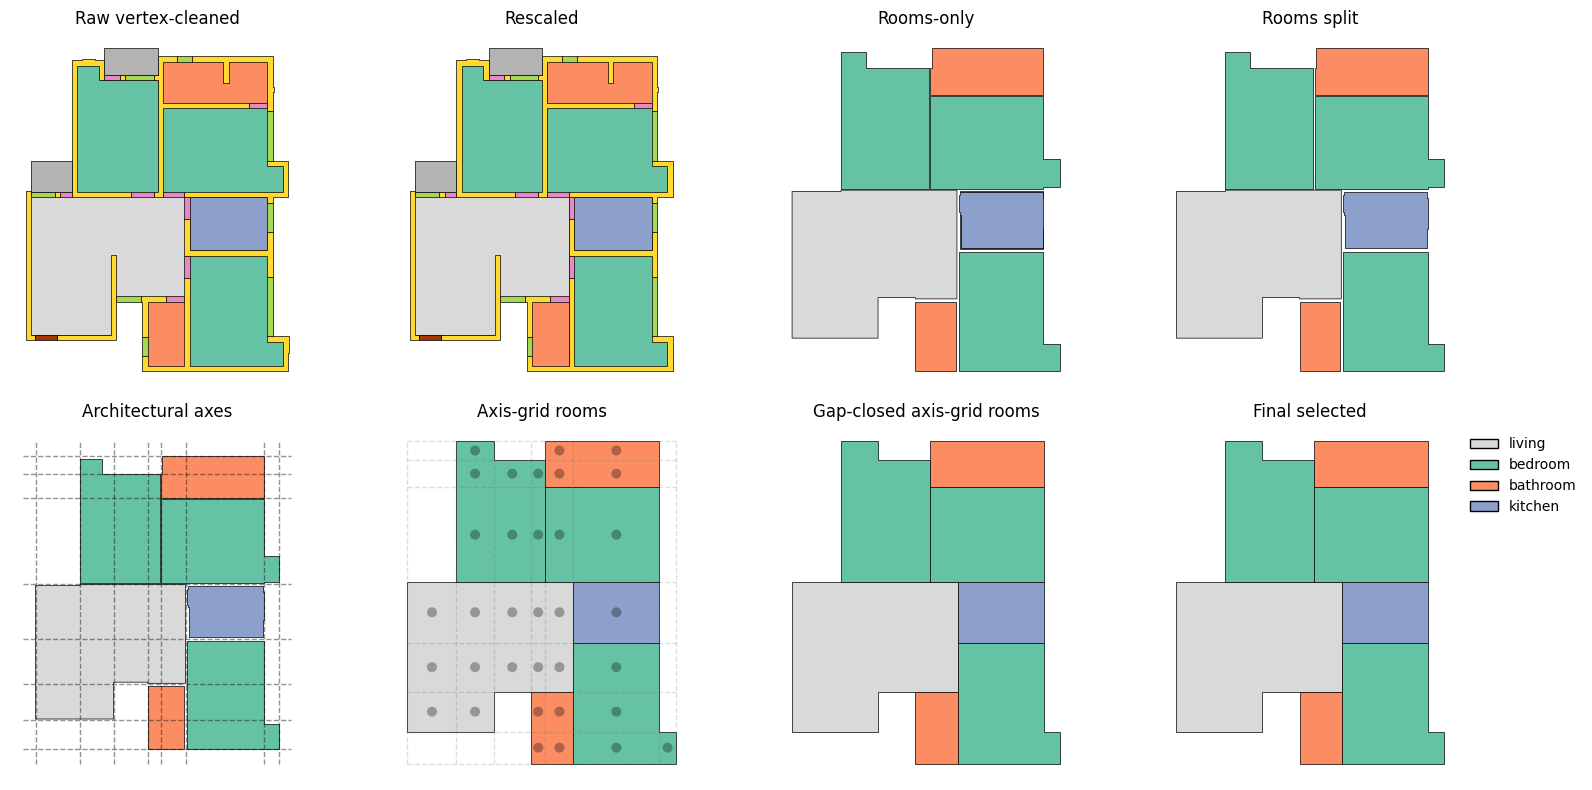

In [17]:
def _diagnostic_polygon_compactness(poly: Polygon) -> float:
    perimeter = float(poly.length)
    if perimeter <= 1e-12:
        return 0.0
    return float((4.0 * math.pi * poly.area) / (perimeter * perimeter))


def _diagnostic_stage_row(step_name: str, plan, *, axis_info=None) -> dict[str, object]:
    room_entries = [
        (label, poly)
        for label, poly in iter_plan_room_polygons(plan, ROOM_KEYS, with_labels=True)
        if isinstance(poly, Polygon) and not poly.is_empty
    ]
    compactness_values = [_diagnostic_polygon_compactness(poly) for _, poly in room_entries]
    area_values = [float(poly.area) for _, poly in room_entries]
    vertex_values = [max(len(poly.exterior.coords) - 1, 0) for _, poly in room_entries]
    worst_idx = int(np.argmin(compactness_values)) if compactness_values else None
    worst_label = room_entries[worst_idx][0] if worst_idx is not None else None

    row = {
        "step": step_name,
        "room_polygons": int(len(room_entries)),
        "concave_rooms": int(concave_polygon_count([poly for _, poly in room_entries])),
        "vertices": int(sum(vertex_values)),
        "min_room_area_m2": float(min(area_values)) if area_values else 0.0,
        "min_compactness": float(min(compactness_values)) if compactness_values else 0.0,
        "skinny_rooms": int(sum(value < SLIVER_COMPACTNESS_THRESHOLD for value in compactness_values)),
        "worst_room_label": worst_label,
    }
    if axis_info is not None:
        row["vertical_axes"] = int(sum(1 for c in axis_info["clusters_after"] if c.get("family") == "vertical"))
        row["horizontal_axes"] = int(sum(1 for c in axis_info["clusters_after"] if c.get("family") == "horizontal"))
    else:
        row["vertical_axes"] = None
        row["horizontal_axes"] = None
    return row


def _diagnostic_transition_summary(stage_rows: list[dict[str, object]]) -> str:
    transition_rows = []
    for prev, curr in zip(stage_rows, stage_rows[1:]):
        compactness_drop = float(prev["min_compactness"]) - float(curr["min_compactness"])
        skinny_increase = int(curr["skinny_rooms"]) - int(prev["skinny_rooms"])
        vertex_jump = int(curr["vertices"]) - int(prev["vertices"])
        if compactness_drop > 0.05 or skinny_increase > 0 or vertex_jump > 2:
            transition_rows.append(
                (
                    curr["step"],
                    compactness_drop,
                    skinny_increase,
                    vertex_jump,
                )
            )

    if not transition_rows:
        return "No strong sliver transition detected across the tracked preprocessing stages."

    culprit_step, compactness_drop, skinny_increase, vertex_jump = max(
        transition_rows,
        key=lambda item: (item[1], item[2], item[3]),
    )
    if culprit_step == "Gap-closed axis-grid rooms":
        culprit_label = "Likely introduced by narrow-gap cleanup."
    elif culprit_step == "Axis-grid rooms":
        culprit_label = "Likely introduced during axis-grid reconstruction / axis clustering."
    else:
        culprit_label = "Likely introduced before the final axis-grid cleanup stages."

    return (
        f"First suspicious transition: {culprit_step} "
        f"(compactness drop {compactness_drop:+.2f}, skinny-room change {skinny_increase:+d}, "
        f"vertex change {vertex_jump:+d}). {culprit_label}"
    )


diagnostic_raw_clean_lookup = _plan_lookup(floorplans_all)
diagnostic_rescaled_lookup = _plan_lookup(rescaled_floorplans)
diagnostic_rooms_lookup = _plan_lookup(floorplans_rooms)
diagnostic_split_lookup = _plan_lookup(floorplans_rooms_split)
diagnostic_pre_gap_lookup = dict(axis_grid_showcase_before_gap_cleanup)
diagnostic_post_gap_lookup = _plan_lookup(floorplans_rooms_axis_grid_all)
diagnostic_final_lookup = _plan_lookup(floorplans_rooms_axis_grid)

for target_id in TARGET_SLIVER_DIAGNOSTIC_IDS:
    stage_entries = [
        ("Raw vertex-cleaned", diagnostic_raw_clean_lookup.get(target_id), None, None),
        ("Rescaled", diagnostic_rescaled_lookup.get(target_id), None, None),
        ("Rooms-only", diagnostic_rooms_lookup.get(target_id), None, None),
        ("Rooms split", diagnostic_split_lookup.get(target_id), None, None),
        ("Architectural axes", diagnostic_split_lookup.get(target_id), floorplan_axes_by_id.get(target_id), None),
        (
            "Axis-grid rooms",
            diagnostic_pre_gap_lookup.get(target_id),
            floorplan_axes_by_id.get(target_id),
            axis_grid_metrics_by_id.get(target_id),
        ),
        ("Gap-closed axis-grid rooms", diagnostic_post_gap_lookup.get(target_id), None, None),
        ("Final selected", diagnostic_final_lookup.get(target_id), None, None),
    ]

    available_entries = [(name, plan, axis_info, grid_metrics) for name, plan, axis_info, grid_metrics in stage_entries if plan is not None]
    if not available_entries:
        print(f"[Sliver diagnostics] id={target_id} is not present in the tracked preprocessing stages.")
        continue

    stage_rows = [
        _diagnostic_stage_row(stage_name, plan, axis_info=axis_info)
        for stage_name, plan, axis_info, _grid_metrics in available_entries
    ]
    print(f"=== Targeted sliver diagnostics for id={target_id} ===")
    display(pd.DataFrame(stage_rows))
    print(_diagnostic_transition_summary(stage_rows))

    ncols = 4
    nrows = int(math.ceil(len(available_entries) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for idx, (stage_name, plan, axis_info, grid_metrics) in enumerate(available_entries):
        ax = axes[idx]
        _plot_plan_or_axes(
            ax,
            stage_name,
            plan,
            axis_info=axis_info,
            axis_grid_metrics=grid_metrics,
            show_legend=(idx == len(available_entries) - 1),
        )
    for ax in axes[len(available_entries):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

### Print a paper-ready preprocessing summary
Summarize the full ResPlan preprocessing pipeline with room-level counts derived from the raw valid plans, the hard-case preselection, and the final aligned subset used for convex decomposition.

In [18]:
def _summary_room_polygons(plan) -> list[Polygon]:
    return [
        poly
        for poly in plan_room_polygons(plan, ROOM_KEYS)
        if isinstance(poly, Polygon) and not poly.is_empty
    ]


def _summary_room_vertex_count(polys: list[Polygon]) -> int:
    return int(sum(max(len(poly.exterior.coords) - 1, 0) for poly in polys))


def _dataset_room_stats(plans) -> dict[str, float | int]:
    polygon_counts = []
    vertex_counts = []
    concave_counts = []

    for plan in plans:
        polys = _summary_room_polygons(plan)
        polygon_counts.append(len(polys))
        vertex_counts.append(_summary_room_vertex_count(polys))
        concave_counts.append(int(concave_polygon_count(polys)))

    return {
        'n_plans': len(polygon_counts),
        'total_polygons': int(sum(polygon_counts)),
        'median_polygons': float(np.median(polygon_counts)) if polygon_counts else 0.0,
        'total_vertices': int(sum(vertex_counts)),
        'median_vertices': float(np.median(vertex_counts)) if vertex_counts else 0.0,
        'total_concave': int(sum(concave_counts)),
    }


raw_all_stats = _dataset_room_stats(floorplans_all_raw)

raw_hard_polygon_counts = []
raw_hard_vertex_counts = []
raw_hard_case_concave_by_id = {}

for fp, scale_factor in zip(preselected_floorplans, preselected_scale_factors):
    polys = scaled_room_polygons_above_area(fp, ROOM_KEYS, scale_factor, MIN_AREA_M2)
    raw_hard_polygon_counts.append(len(polys))
    raw_hard_vertex_counts.append(_summary_room_vertex_count(polys))
    raw_hard_case_concave_by_id[fp.get('id')] = int(concave_polygon_count(polys))

raw_hard_case_polygon_total = int(sum(raw_hard_polygon_counts))
raw_hard_case_polygon_median = float(np.median(raw_hard_polygon_counts)) if raw_hard_polygon_counts else 0.0
raw_hard_case_vertex_total = int(sum(raw_hard_vertex_counts))
raw_hard_case_vertex_median = float(np.median(raw_hard_vertex_counts)) if raw_hard_vertex_counts else 0.0
raw_hard_case_concave_total = int(sum(raw_hard_case_concave_by_id.values()))
raw_hard_case_concave_pct = (
    100.0 * raw_hard_case_concave_total / raw_hard_case_polygon_total
    if raw_hard_case_polygon_total
    else 0.0
)

valid_thickness = room_offset_summary_df.loc[
    room_offset_summary_df['wall_thickness_m'] > 0, 'wall_thickness_m'
]
wall_thickness_count = int(len(valid_thickness))
wall_thickness_median = float(valid_thickness.median()) if not valid_thickness.empty else 0.0

orthogonal_plan_count = int(axis_summary_df['orthogonal_only'].sum()) if not axis_summary_df.empty else 0
mean_vertical_axes = float(axis_summary_df['vertical_axes_after'].mean()) if not axis_summary_df.empty else 0.0
mean_horizontal_axes = float(axis_summary_df['horizontal_axes_after'].mean()) if not axis_summary_df.empty else 0.0

axis_grid_rebuilt_count = int(len(axis_grid_reconstruction_summary_df))
axis_grid_abs_area_error_mean = (
    float(axis_grid_reconstruction_summary_df['total_abs_area_error_m2'].mean())
    if not axis_grid_reconstruction_summary_df.empty
    else 0.0
)
axis_grid_symdiff_mean = (
    float(axis_grid_reconstruction_summary_df['total_label_symdiff_m2'].mean())
    if not axis_grid_reconstruction_summary_df.empty
    else 0.0
)
axis_grid_vertices_removed = int(geometry_cleanup_stats['removed_vertices'])

preprocessed_candidate_count = int(len(floorplans_rooms_axis_grid_all))
min_area_discarded_count = int(len(small_room_plan_ids_preprocessing))

resolved_hard_case_count = int(raw_hard_case_count_before - current_hard_case_count)
resolved_hard_case_pct = (
    100.0 * resolved_hard_case_count / raw_hard_case_count_before
    if raw_hard_case_count_before
    else 0.0
)

final_concave_by_id = {
    plan.get('id'): int(_concave_room_count(plan))
    for plan in floorplans_rooms_axis_grid_all
}
resolved_concave_room_total = int(sum(
    max(raw_hard_case_concave_by_id.get(plan_id, 0) - final_concave_by_id.get(plan_id, 0), 0)
    for plan_id in raw_hard_case_concave_by_id
))
resolved_concave_room_pct = (
    100.0 * resolved_concave_room_total / raw_hard_case_concave_total
    if raw_hard_case_concave_total
    else 0.0
)

final_selected_stats = _dataset_room_stats(floorplans_rooms_axis_grid)
final_selected_concave_pct = (
    100.0 * final_selected_stats['total_concave'] / final_selected_stats['total_polygons']
    if final_selected_stats['total_polygons']
    else 0.0
)

print('=== ResPlan preprocessing paper summary ===')
print(
    f"We loaded {len(floorplans_all_raw)} valid floorplans, containing "
    f"{raw_all_stats['total_polygons']} room polygons "
    f"(median {raw_all_stats['median_polygons']:.1f} per floorplan) and "
    f"{raw_all_stats['total_vertices']} room vertices "
    f"(median {raw_all_stats['median_vertices']:.1f} per floorplan)."
)
print(
    f"A raw room-vertex cleanup removed {raw_vertex_cleanup_stats['removed_vertices']} redundant room vertices "
    f"({100.0 * raw_vertex_cleanup_stats['removed_vertices'] / max(raw_vertex_cleanup_stats['before_vertices'], 1):.1f}%), "
    f"changing {raw_vertex_cleanup_stats['changed_room_geometries']} room geometries."
)
print(
    f"Using a raw concavity preselection, we kept {raw_hard_case_count_before} / {len(floorplans_all)} "
    f"floorplans with at least {RAW_PRESELECTION_MIN_CONCAVE_ROOMS} concave room polygons "
    f"({raw_preselection_pct:.1f}%)."
)
print(
    f"These selected raw hard cases contain {raw_hard_case_polygon_total} room polygons, of which "
    f"{raw_hard_case_concave_total} are concave ({raw_hard_case_concave_pct:.1f}%), and "
    f"{raw_hard_case_vertex_total} room vertices (median {raw_hard_case_vertex_median:.1f} per floorplan)."
)
print(
    f"We rescale these {len(rescaled_floorplans)} floorplans and estimated wall thickness for "
    f"{wall_thickness_count} / {len(room_offset_summary_df)} plans "
    f"(median {wall_thickness_median:.3f} m), then offset room polygons into wall space."
)
print('We then split multipart rooms into explicit polygon parts and regularized the plans on an architectural axis grid.')
print(
    f"Orthogonal family locking was applied to {orthogonal_plan_count} / {len(rescaled_floorplans)} floorplans, "
    f"keeping on average {mean_vertical_axes:.2f} vertical and {mean_horizontal_axes:.2f} horizontal axes per plan."
)
print(
    f"Axis-grid reconstruction rebuilt {axis_grid_rebuilt_count} / {len(rescaled_floorplans)} floorplans, "
    f"with mean absolute room-area error {axis_grid_abs_area_error_mean:.2f} m^2 and "
    f"mean symmetric-difference error {axis_grid_symdiff_mean:.2f} m^2, while removing "
    f"{axis_grid_vertices_removed} redundant reconstruction vertices."
)
print(
    f"Narrow-gap cleanup changed {gap_cleanup_stats['plans_changed']} / {len(rescaled_floorplans)} floorplans "
    f"by closing {gap_cleanup_stats['gaps_closed']} narrow gaps, absorbing "
    f"{gap_cleanup_stats['total_gap_area_m2']:.2f} m^2."
)
print(
    f"The minimum-room-area filter discarded {min_area_discarded_count} floorplans with room parts below "
    f"{MIN_AREA_M2:.1f} m^2, leaving {preprocessed_candidate_count} preprocessed candidates."
)
print(
    f"After preprocessing, {current_hard_case_count} / {preprocessed_candidate_count} floorplans still contain "
    f"at least {RAW_PRESELECTION_MIN_CONCAVE_ROOMS} concave room polygons ({final_selected_pct:.1f}%), "
    f"retaining {retained_hard_case_pct:.1f}% of the original hard cases."
)
print(
    f"This means that {resolved_hard_case_count} ({resolved_hard_case_pct:.1f}%) floorplans with earlier at least "
    f"{RAW_PRESELECTION_MIN_CONCAVE_ROOMS} concave zones now have 2 or fewer concave zones and in total, "
    f"across all floorplans {resolved_concave_room_total} earlier concave rooms "
    f"({resolved_concave_room_pct:.1f}%) are no longer concave after the preprocessing pipeline."
)
print(
    f"For convex decomposition, this yields {len(floorplans_rooms_axis_grid)} aligned floorplans containing "
    f"{final_selected_stats['total_polygons']} room polygons, of which {final_selected_stats['total_concave']} "
    f"are concave ({final_selected_concave_pct:.1f}%), and {final_selected_stats['total_vertices']} room vertices "
    f"(median {final_selected_stats['median_vertices']:.1f} per floorplan)."
)


=== ResPlan preprocessing paper summary ===
We loaded 17000 valid floorplans, containing 140295 room polygons (median 7.0 per floorplan) and 1050808 room vertices (median 56.0 per floorplan).
A raw room-vertex cleanup removed 19424 redundant room vertices (1.6%), changing 5350 room geometries.
Using a raw concavity preselection, we kept 11691 / 17000 floorplans with at least 3 concave room polygons (68.8%).
These selected raw hard cases contain 92470 room polygons, of which 47794 are concave (51.7%), and 708524 room vertices (median 56.0 per floorplan).
We rescale these 11691 floorplans and estimated wall thickness for 11691 / 11691 plans (median 0.230 m), then offset room polygons into wall space.
We then split multipart rooms into explicit polygon parts and regularized the plans on an architectural axis grid.
Orthogonal family locking was applied to 11137 / 11691 floorplans, keeping on average 7.39 vertical and 6.91 horizontal axes per plan.
Axis-grid reconstruction rebuilt 11691 / 1